<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<b>Привет, Андрей!👋</b>
    
Меня зовут Зуева Юлия, можно просто Юля 😏 Я буду ревьюером твоего проекта. Предлагаю обращаться на "ты", но если это неудобно, пожалуйста, скажи об этом! 
    
Моя основная цель - помочь тебе стать компетентным Data Scientist'ом: вместе преодолеть трудности и еще больше развить твои сильные навыки 💪 В твоей работе я оставила комментарии, которые должны в этом помочь. Для твоего удобства комментарии раскрашены разными цветами: 
<br/>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> В случае корректного решения (или отдельных его моментов). На такие решения можно опираться в будущем.
</div>
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> Если есть возможность как-либо улучшить решение. Ты можешь учесть эти комментарии при доработке проекта, однако для зачета это не обязательно.
</div>
<div style="border-radius: 10px" class="alert alert-block alert-danger">
<b>Нужно доработать ❌:</b> Если решение требует внесения правок. Проект не может быть принят, если остались не отработанные комментарии данного типа.
</div>
    
Чтобы наша с тобой работа была еще эффективнее, ты точно так же можешь оставлять комментарии и задавать мне вопросы. Для таких случаев, пожалуйста, выбери собственное оформление комментариев, которое будет отличаться от моего, чтобы не создавалась путаница. По этой же причине попрошу тебя не удалять и не изменять мои комментарии. Все это позволит лучше ориентироваться в нашем с тобой диалоге, а повторную проверку (в случае ее необходимости) выполнять оперативнее 🚀
    
Не спеши расстраиваться, если что-то не удалось с первого раза. Вместе мы обязательно разберемся со всеми трудностями! 🤓

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Здравствуй, Юля! Ты уже проверяла какую-то мою работу, рад встретиться снова. Сразу хочу поблагодарить за потраченное время и обстоятельные комментарии!
</div>

# Анализ лояльности пользователей Яндекс Афиши
- Автор: Андрей Творогов
- Дата: 22.02.2026

## Цели и задачи проекта
Цель проекта -  понять, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно.
Для достижения этой цели необходимо выпонить следующие задачи:
- Загрузка данных для анализа из СУБД.
- Предобработка данных с использованием возможностей библиотеки `pandas`.
- Построение профилей пользователей, содержащих агрегатные показатели заказов этих пользователей.
- Исследовательский анализ данных, включающий изучение взаимосвязи разных параметров профиля пользователя с количеством сделанных им заказов.

## Описание данных

Данные для анализа располагаются в схеме `afisha` базы данных `data-analyst-afisha` которая содержит пять таблиц.

#### Таблица `purchases`

Содержит информацию о заказах билетов:

- `order_id` — идентификатор заказа;
- `user_id` — идентификатор пользователя, совершившего заказ;
- `created_dt_msk` — дата создания заказа по московскому времени;
- `created_ts_msk` — дата и время создания заказа по московскому времени;
- `event_id` — идентификатор мероприятия из таблицы `events`;
- `cinema_circuit` — сеть кинотеатров, где проходит мероприятие. Если оно проходит не в кинотеатре, то здесь будет значение `нет`;
- `age_limit` — возрастное ограничение мероприятия;
- `currency_code` — валюта оплаты;
- `device_type_canonical` — тип устройства, с которого был оформлен заказ (например, `mobile` — мобильные устройства, `desktop` — компьютеры);
- `revenue` — выручка от заказа;
- `service_name` — название билетного оператора;
- `tickets_count` — количество купленных билетов;
- `total` — общая сумма заказа.

#### Таблица `events`

Содержит данные о мероприятиях, доступных на платформе:

- `event_id` — идентификатор мероприятия.
- `event_name_code` — название мероприятия в закодированном виде.
- `event_type_description` — описание мероприятия.
- `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее)
- `organizers` — организаторы мероприятия.
- `city_id` — идентификатор города проведения мероприятия из таблицы `cities`.
- `venue_id` — идентификатор площадки проведения мероприятия из таблицы `venues`.

#### Таблица `venues`

Содержит сведения о площадках проведения мероприятий:

- `venue_id` — идентификатор площадки;
- `venue_name` — название площадки;
- `address` — адрес площадки.

#### Таблица `city`

Содержит список городов, относящихся к регионам:

- `city_id` — идентификатор города;
- `city_name` — название города;
- `region_id` — идентификатор региона, в котором расположен город, из таблицы `regions`.

#### Таблица `regions`

Содержит список регионов, в которых проводятся мероприятия:

- `region_id` — идентификатор региона;
- `region_name` — название региона.

## Структура проекта
1. [Загрузка данных.](#1-загрузка-данных)
2. [Предобработка данных.](#2-предобработка-данных)
3. [Построение профилей пользователей.](#3-построение-профилей-пользователей)
4. [Исследовательский анализ данных.](#4-исследовательский-анализ-данных)<br>
    4.1 [Исследование признаков первого заказа.](#41-исследование-признаков-первого-заказа)<br>
    4.2 [Исследование поведения пользователей через показатели выручки и состава заказа.](#42-исследование-поведения-пользователей-через-показатели-выручки-и-состава-заказа)<br>
    4.3.[Исследование временных характеристик первого заказа и их влияния на повторные покупки.](#43-исследование-временных-характеристик-первого-заказа-и-их-влияния-на-повторные-покупки)<br>
    4.4.[Корреляционный анализ количества покупок и признаков пользователя.](#44-корреляционный-анализ-количества-покупок-и-признаков-пользователя)<br>
5. [Выводы](#5-выводы)

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Вводная часть <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Здорово, что оставляешь вводную часть! Она помогает быстро понять цель, контекст и структуру работы, что будет удобно не только для тебя при возвращении к проекту спустя время, но и любому другому читателю (если, например, публикуешь в открытый доступ для портфолио). Воспринимаем эту тетрадку не просто как выполнение домашней работы на курсе, а как полноценный исследовательский проект.

Как правило, во вводную часть включают название проекта, краткое описание цели, используемых данных (источники, объем, особенности), нюансы самого проекта (специфические условия, ограничения, предположения и т.д.). Иногда также сразу обозначают план шагов. Другими словами, вводная часть призвана отразить, что мы делаем, с чем работаем и на каких условиях.
</div>


## 1. Загрузка данных

- Установка дополнительных библиотек:

In [409]:
# Установка зависимостей через requirements.txt не работает из-за несоответствия версии jupyter_core
#%pip install -r requirements.txt

%pip install -q python-dotenv
%pip install -q phik
%pip install -q --upgrade seaborn
%pip install -q --upgrade sqlalchemy
%pip install -q --upgrade jinja2

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


- Импорт необходимых библиотек:

In [410]:
# Библиотеки для загрузки параметров из файлов .env
import os
from dotenv import load_dotenv

# Для форматирования в HTML
from IPython.display import display, HTML, Markdown

import pandas as pd
import numpy as np

# Библиотека для доступа к СУБД
from sqlalchemy import create_engine

# Библиотеки для построения графиков
import seaborn as sns
import matplotlib.pyplot as plt

# Библиотека phik для анализа корреляций
import phik

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Импорты <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Здорово, что все необходимые библиотеки подгружаешь сразу в начале проекта! Это соответствует стандартам оформления кода <a href='https://pyplanet.ru/article/pep-0008.html'>PEP 8</a>. Такой подход позволяет сразу видеть, какое окружение необходимо для запуска проекта, избежать дублирования импортов в разных частях кода, а также облегчить отладку и переносимость проекта.
    
    
* Хорошей практикой также является упорядочивание импортов. PEP 8 рекомендует сначала подгружать стандартные python-библиотеки, затем сторонние. Но для удобства каждую их этих групп также можно структурировать по тематике. Например, библиотеки для работы с данными, для работы с графиками и т.д. Так удобнее поддерживать порядок в импортах от проекта к проекту, не подгружать лишнее.


</div>

<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> Чтобы при установке новой библиотеки не выводилась информация о процессе и зависимостях, можно добавлять опцию `--quiet` или просто `-q`. 
     
</div>

- Установка параметров соединения с СУБД:

In [411]:
# Загрузка файла конфигурации
load_dotenv()

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    os.getenv("DB_USER"),
    os.getenv("DB_PASSWORD"),
    os.getenv("DB_HOST"),
    os.getenv("DB_PORT"),
    os.getenv("DB_NAME")
)


- Создание соединения с СУБД, выполнение SQL-запроса и загрузка данных в датафрейм::

In [412]:
# Создание пула соединений
engine = create_engine(connection_string) 

query = '''
SELECT
	user_id,
	device_type_canonical,
	order_id,
	created_dt_msk AS order_dt,
	created_ts_msk AS order_ts,
	currency_code,
	revenue,
	tickets_count,
	EXTRACT (DAY FROM (created_dt_msk - LAG(created_dt_msk, 1, NULL) 
				OVER (PARTITION BY user_id ORDER BY created_dt_msk))) AS days_since_prev,
	event_id,
	event_name_code AS event_name,
	service_name,
	event_type_main,
	region_name,
	city_name
FROM
	afisha.purchases
	INNER JOIN afisha.events USING(event_id)
	INNER JOIN afisha.city USING(city_id)
	INNER JOIN afisha.regions USING (region_id)
WHERE
	device_type_canonical IN ('mobile', 'desktop')
	AND event_type_description <> 'фильм'
ORDER BY user_id
''' 

# Загрузка данных в датафрейм
df = pd.read_sql_query(query, con=engine) 

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Загрузка данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* Выгрузка данных проведена корректно! Была выполнена необходимая фильтрация данных, выгружены только необходимые для анализа данные. Отлично, что сразу подсчитываешь время между заказами для каждого пользователя.
    
    
* Здорово, что засекречиваешь подключение! Лучше сразу в процессе работы держать чувствительные значения отдельно от основного содержания, иначе есть высокий риск забыть об этом нюансе.

</div>

- Пример данных и количество строк:

In [413]:
initial_count = len(df)

print("Количество строк в датасете: ", initial_count)
display(df.head(5))

Количество строк в датасете:  290611


,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,service_name,event_type_main,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,Край билетов,театр,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,Мой билет,выставки,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,За билетом!,другое,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,Лови билет!,другое,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,Билеты без проблем,стендап,Озернинский край,Родниковецк


- Описание датасета:

In [414]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  str           
 1   device_type_canonical  290611 non-null  str           
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[us]
 4   order_ts               290611 non-null  datetime64[us]
 5   currency_code          290611 non-null  str           
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  str           
 11  service_name           290611 non-null  str           
 12  event_type_main        290611 non-null  str           


**Вывод:**
Пропуски присутствуют только в столбце `days_since_prev`, что соответствует условию задания. В соответствии с наличием пропусков тип поля - `float64`, а не `intXX`. Пропуски присутствуют у первых заказов, для которых не существует предыдущих.
<br><br>
На этапе предобработки данных необходимо будет произвести следующие преобразования и проверки:
- Привести выручку к одной валюте - рублю с созданием нового столбца.
- Уменьшить размерность числовых типов данных.
- Проверить категориальные данные на наличие дубликатов и заглушек.
- Выполнить проверку на дубликаты.
- Убедиться в том, что в столбце `days_since_prev` пропуски действительно соответствуют только первым заказам.
- Проверить числовые столбцы на выбросы и заведомо ошибочные значения.

<div style="border:solid #D3D3D3 2px; border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Проверка корректности загруженных данных <a class="tocSkip"></h4>
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 

* Хорошо, что убеждаешь в корректности данных! Если при подгрузке возникли проблемы, а мы их не обнаружим, все последующие расчеты могут быть искажены.

    
* Круто, что не забываешь зафиксировать промежуточные наблюдения в выводах! Если потребуется вернуться к проекту спустя время, будет проще освежить в памяти все ключевые этапы работы, что и почему мы делали, что получили.

</div>
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>
    
* Стоит предположить, что пропуски, скорее всего, образовались на первых заказах пользователей, в таком случае у них не существует предыдущего, от которого можно было бы посчитать количество дней.

    
* По результатам проверки корректности загруженных данных мы планируем дальнейшие шаги по обработке. Здесь можно было бы отметить, что нам потребуется привести выручку к единой валюте, убедиться, что пропуски действительно имеются только у первых заказов, выполнить проверку на дубликаты (полные и неполные), проверить категориальные столбцы на предмет неявных дубликатов (разный регистр, разный формат записи, опечатки) и все числовые столбцы на наличие невалидных значений и аномалий, опционально сменить типы данных на более оптимальные, чтобы уменьшить объем занимаемой памяти.
    
</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Дополнил выводы.
</div>

## 2. Предобработка данных

### 2.1. Приведение выручки к одной валюте - рублю

- Загрузка информации о курсах валют и добавление столбца `revenue_rub` с суммой в рублях:

In [415]:
# Вывод всех валют в датасете
print("Валюты в датасете: ", ", ".join(df['currency_code'].unique()))

# Загрузка датасета
df_curr_course = pd.read_csv("https://code.s3.yandex.net/datasets/final_tickets_tenge_df.csv")

# Проверим диапазон значений курса
print("\nДиапазон значений курса:")
display(df_curr_course['curs'].agg(['min', 'max']))

# Проверим наличие дубликатов
print("Количество дубликатов курса по дате: ", df_curr_course['data'].duplicated().sum())

# Добавление столбца с типом datetime64 для соединения с основным датасетом
df_curr_course['date'] = pd.to_datetime(df_curr_course['data'], format='%Y-%m-%d')

# Соединение датасетов по дате
df_tmp = df.merge(df_curr_course, left_on='order_dt', right_on='date', how="left")

# Добавление столбца с суммой в рублях
# df['revenue_rub'] = df_tmp.apply(lambda r: r['revenue'] if r['currency_code']=='rub' else r['revenue']*r['curs']/100.0,
#                                  axis=1)
df['revenue_rub'] = df_tmp['revenue'].where(df_tmp['currency_code'] == 'rub', 
                                            df_tmp['revenue'] * df_tmp['curs'] / 100)

# Проверка
display(df[df['currency_code']=='kzt'][['revenue', 'revenue_rub', 'currency_code']].head())
display(df[df['currency_code']=='rub'][['revenue', 'revenue_rub', 'currency_code']].head())
print("Количество пропусков: ", df['revenue_rub'].isna().sum())

Валюты в датасете:  rub, kzt

Диапазон значений курса:


min    17.8486
max    21.9371
Name: curs, dtype: float64

Количество дубликатов курса по дате:  0


,revenue,revenue_rub,currency_code
70,518.10,98.503762,kzt
89,347.18,65.731589,kzt
96,328.77,61.148261,kzt
277,22021.55,4380.702898,kzt
460,7397.66,1478.296591,kzt


,revenue,revenue_rub,currency_code
0,1521.94,1521.94,rub
1,289.45,289.45,rub
2,1258.57,1258.57,rub
3,8.49,8.49,rub
4,1390.41,1390.41,rub


Количество пропусков:  0


<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Перевод выручки в рубли <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> С шагом справились, результат корректный!
</div>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 
    
* Сперва следовало убедиться в корректности данных с курсом, по всем ли датам есть курс, адекватные ли там значения, нет ли дубликатов, а уже потом переходить к конвертации.


* Вместо цикличного `apply` (который за раз работает с одной строкой, и при этом еще вынужден каждый раз проходиться по еще одной таблице, что очень долго и затратно) лучше использовать довольно удобный метод [where](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.where.html). Мы можем присоединить курс к нашей таблице с пользователями, применить данный метод к столбцу с выручкой и указать условие, которое будем проверять, а также альтернативный вариант значения. Если условие выполняется, то берется значение из столбца, если нет - альтернативное значение. Тогда расчет выручки в рублях будет выглядеть следующим образом:
    
    ```python
df['revenue_rub'] = df['revenue'].where(df['currency_code'] == 'rub', df['revenue'] * df['curs'] / 100)
```

* После проведения каких-либо манипуляций с данными необходимо убеждаться, что все выполнилось корректно. Для проверки результата стоит вывести на обозрение только связанные с данной задачей столбцы, чтобы не перегружать читателя лишним. При этом проверить оба кейса, и когда корректировка требовалась, и когда нет, убедиться, что не образовалось пропусков.


</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Добавил проверку датасета с курсами и результата.
</div>

### 2.2. Проверка категориальных данных

- Проверим типы мероприятий:

In [416]:
display(pd.DataFrame(df['event_type_main'].unique()))

,0
0,театр
1,выставки
2,другое
3,стендап
4,концерты
5,спорт
6,ёлки


Значение `'другое'` является заглушкой, это надо учитывать при дальнейшем анализе.

- Проверим наличие дубликатов и некорректных данных в столбцах регионов и билетных операторов:

In [417]:
def show_scrollable(list):
    html_content = """
    <div style="height:200px; overflow:auto; border:1px solid black; padding:5px;">
    {}
    </div>
    """.format("<br>".join(list))
    display(HTML(html_content))

show_scrollable(sorted(df['service_name'].unique().tolist()))
show_scrollable(sorted(df['region_name'].unique().tolist()))
show_scrollable(sorted(df['city_name'].unique().tolist()))
print("Наличие дубликатов в названии городов с точностью до регистра: ", 
      len(df['city_name'].unique()) != len(df['city_name'].str.lower().unique()))

Наличие дубликатов в названии городов с точностью до регистра:  False


- Среди регионов есть две похожие пары: Крутоводская область/Крутоводский регион и Речицкая область/Речицкий регион.
- Среди городов также есть пары похожих, например, Речинск и Реченск. 
- Поскольку названия вымышленные, проверить по внешним источникам, являются ли они дубликатами, нельзя - оставим как есть.
- Среди билетных операторов дубликатов и некорректных значений нет.

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Добавил проверку категориальных данных.
</div>

### 2.3. Проверка наличия дубликатов в заказах
- Проверим, есть ли дубликаты среди заказов:

In [418]:
columns_dup = df.columns.to_list()
columns_dup.remove('order_id')
columns_dup.remove('days_since_prev')

duplicates_count = df.duplicated(subset=columns_dup).sum()
print("Количество дубликатов:", duplicates_count)

Количество дубликатов: 40


- Дубликаты могли появиться, например, в результате двойного нажатия на кнопку оформления заказа в веб-приложении.
<br><br>
Удалим дубликаты и пересчитаем параметр `days_since_prev`:

In [419]:
df.drop_duplicates(subset=columns_dup, inplace=True)

# Отсортируем заказы и пересчитаем количество дней от предыдущего заказа
df = df.sort_values(by='order_ts')
df['days_since_prev'] = df.groupby(by='user_id')['order_dt'].diff().dt.days

prev_count = len(df)
print(f"Новое количество строк: {len(df)}, удалено {initial_count-len(df)} строк")

Новое количество строк: 290571, удалено 40 строк


<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Добавил проверку и удаление дубликатов.
</div>

### 2.4. Проверка выбросов и некорректных числовых значений

- Построим гистограмму распределения выручки `revenue_rub`:

In [420]:
# Функция для построения гистограммы
def draw_histogram(title,
                   xlabel, 
                   ylabel, 
                   figsize=(12, 4),
                   **kwargs):
    plt.figure(figsize=figsize)
    sns.histplot(**kwargs)

    # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

# Функция для построения гистограммы и боксплота на одной шкале
def draw_double_diag(data, title, x, hue, xlabel, ylabel, stat='count', figsize=(12, 6), bins='auto', kde=True):
    fig, (ax_hist, ax_box) = plt.subplots(
        nrows=2,
        ncols=1,
        sharex=True,
        figsize=figsize,
        gridspec_kw={'height_ratios': [2, 1]}
    )

    sns.boxplot(data=data,
                ax=ax_box,
                x=x, 
                hue=hue, 
                showmeans=True,
                legend=False,
                meanprops={
                    "marker": "o",
                    "markerfacecolor": "white",
                    "markeredgecolor": "black",
                    "markersize": 8
                })

    ax_box.set_xlabel('')  # Убираем подпись оси X, чтобы не дублировалась
    ax_box.set_ylabel('')  # Убираем подпись оси Y
    ax_box.set_yticks([])  # Убираем тики оси Y (они не нужны)

    sns.histplot(data=data,
                ax=ax_hist,
                x=x,
                hue=hue,
                kde=kde,
                bins=bins,
                stat=stat)

    ax_hist.set_xlabel(xlabel)
    ax_hist.set_ylabel(ylabel)

    fig.suptitle(title, fontsize=14)

    plt.tight_layout()
    plt.show()

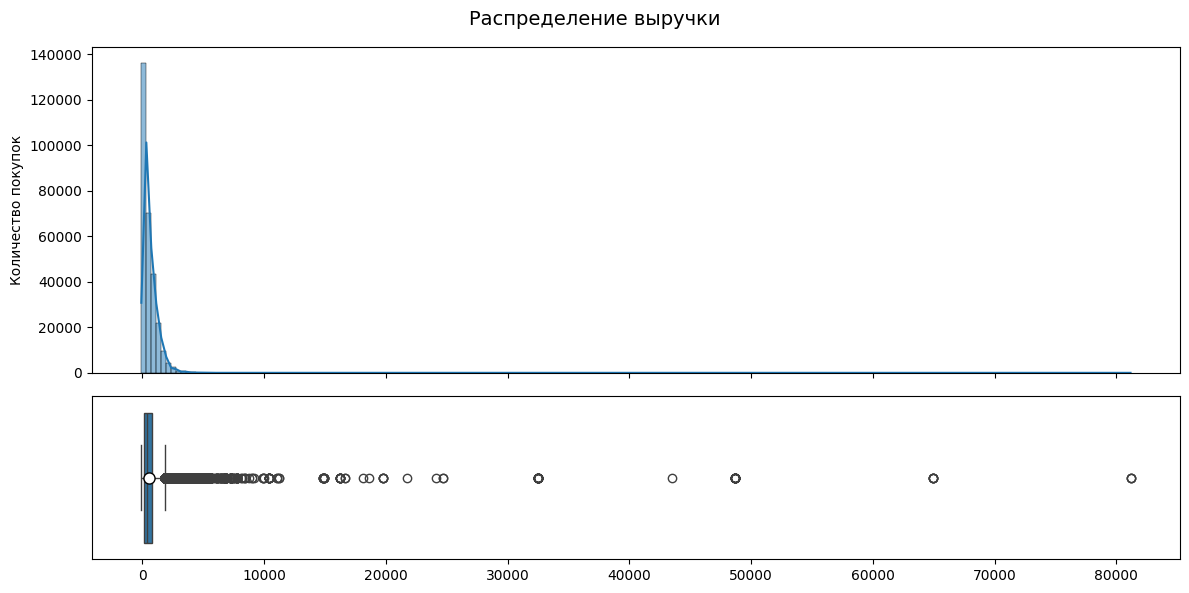

In [421]:
# Гистограмма распределения выручки
draw_double_diag(df,
                 "Распределение выручки",
                 'revenue_rub',
                 None,
                 "Выручка",
                 "Количество покупок",
                 bins=200
                 )

Значения выручки `revenue_rub` содержат выбросы. Попробуем определить, к каким мероприятиям они относятся:

In [422]:
df_rev_by_event = df.groupby(by=['event_type_main', 'event_name'])['revenue_rub'].agg(['max', 'min', 'mean'])
df_rev_by_event.sort_values('max', ascending=False).head(10)

max      min  \
event_type_main event_name                                                
концерты        b443dc5a-fff2-4b69-8684-0719fff49b59  81174.54   101.54   
                9cc55c15-4375-4129-9979-3129688ba1b4  43515.08    88.69   
стендап         340e1e70-82b3-4489-9ae6-b8d9d47b5523  24680.88  1141.44   
концерты        61f1eff3-f1ad-40c9-b503-b778b91cead9  24124.85   228.11   
спорт           d4d907c8-3bdd-4df1-b7e6-4c6a9d74df4c  18641.92  7456.77   
концерты        58574140-962c-49a3-af70-b773a05661a3  16617.94    73.40   
                a4bc5bde-7eb1-4d4e-b846-14b4da9cc8be   9954.66   121.83   
                e1a58a1f-b479-4b93-8636-82f5d7e7cd83   9128.27   492.58   
                ff0b67ed-4f78-44f9-8b3f-ea2e63d238ff   9036.12   249.60   
спорт           fe374a3e-b9cc-4b93-89a7-08329cdedc09   8748.14  4374.07   

                                                              mean  
event_type_main event_name                                          
концерты        b443dc5a-fff2-4b69-8684-0719fff49b59   5116.499060  
                9cc55c15-4375-4129-9979-3129688ba1b4   1037.703061  
стендап         340e1e70-82b3-4489-9ae6-b8d9d47b5523   6341.103800  
концерты        61f1eff3-f1ad-40c9-b503-b778b91cead9   1617.117594  
спорт           d4d907c8-3bdd-4df1-b7e6-4c6a9d74df4c  12540.925455  
концерты        58574140-962c-49a3-af70-b773a05661a3    922.032028  
                a4bc5bde-7eb1-4d4e-b846-14b4da9cc8be   1741.559941  
                e1a58a1f-b479-4b93-8636-82f5d7e7cd83   1437.287881  
                ff0b67ed-4f78-44f9-8b3f-ea2e63d238ff   1831.330357  
спорт           fe374a3e-b9cc-4b93-89a7-08329cdedc09   6561.103333

- Самые дорогие билеты были проданы на концерт, стендап и спортивные мероприятия. Для концертов разброс цен от 100р. до 80000р. вполне реален - самые дешевые билеты - на стоячие места, самые дорогие - в VIP-зону, могут включать встречу с артистом и проч. бонусы. Билеты на спортивные мероприятия уровня чемпионата мира также могут стоить 10000-20000 р. и более.
- Несмотря на то, что данные с аномально большой выручкой не являются ошибочными, их стоит удалить, потому что они по объему составляют менее 1%, однако влияют на статистику *(здесь когда-то будет оценка статистической значимости :)*.

- Отфильтруем записи по 99 процентилю в этом поле, а также удалим отрицательные значения:

Первоначальное количество строк: 290571.
Количество строк после удаления: 281658.
Удалено строк: 8913 (3.07%)


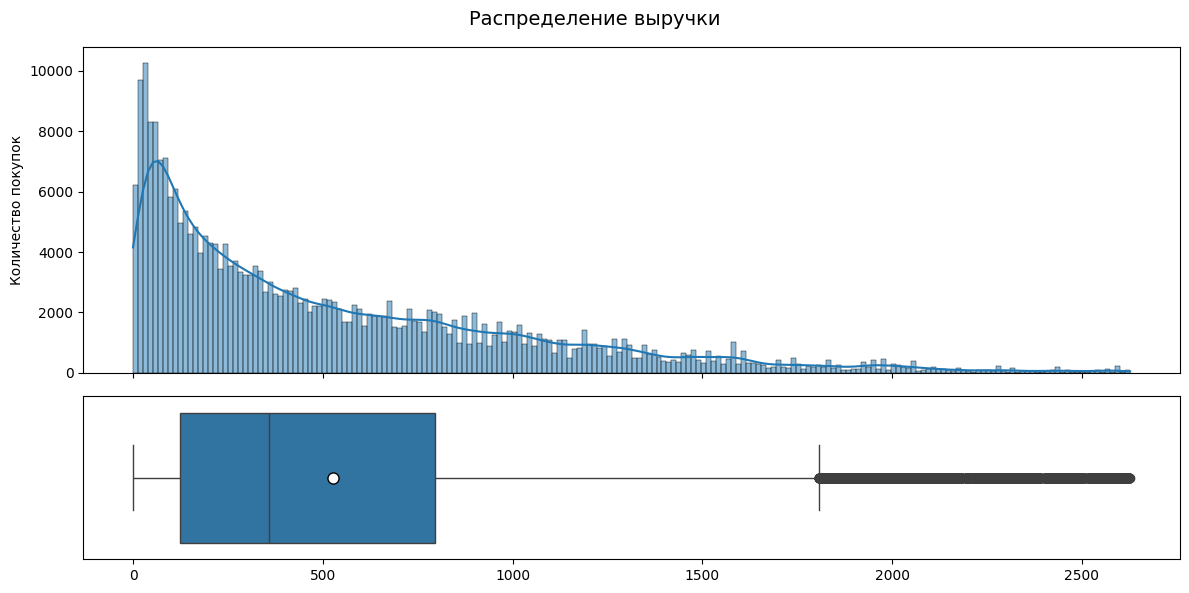

In [423]:
# Получаем 99 процентиль с положительным revenue_rub
percentile_99 = df['revenue_rub'].quantile(0.99)

# Удаляем выбросы и отрицательные значения
df = df[(df['revenue_rub']>0.0) & (df['revenue_rub']<percentile_99)]
anomalies_count = prev_count - len(df)
anomalies_perc = round(anomalies_count/prev_count*100.0, 2)

print(f"Первоначальное количество строк: {prev_count}.")
print(f"Количество строк после удаления: {len(df)}.")
print(f"Удалено строк: {anomalies_count} ({anomalies_perc}%)")

# Гистограмма распределения выручки
draw_double_diag(df,
                 "Распределение выручки",
                 'revenue_rub',
                 None,
                 "Выручка",
                 "Количество покупок",
                 bins=200
                 )


- Построим диаграмму распределения количества билетов:

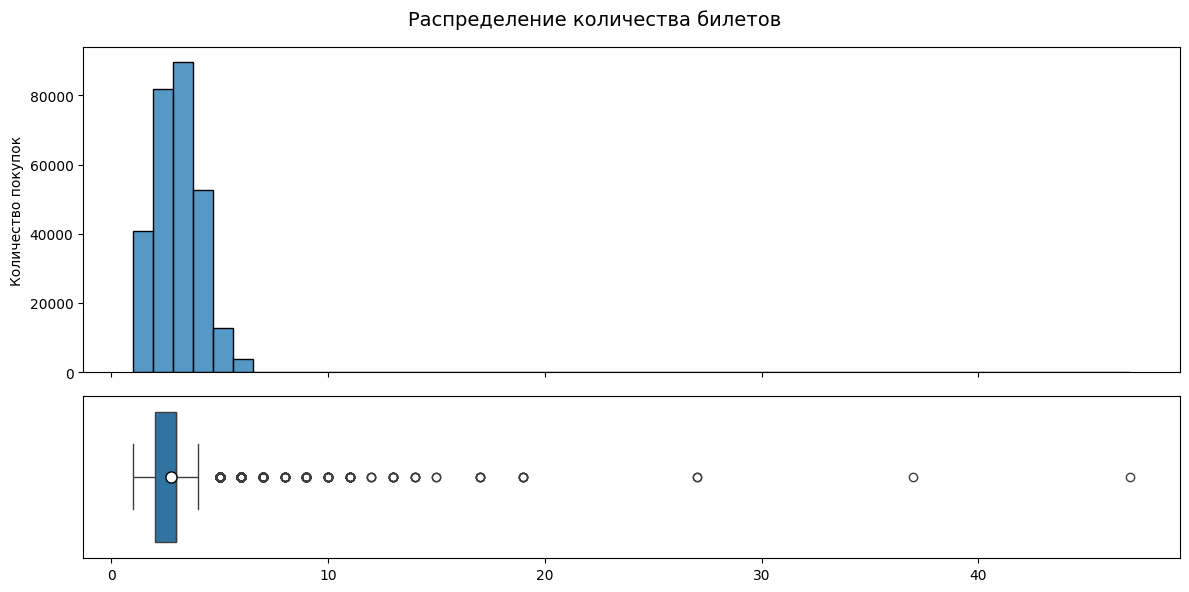

In [424]:
# Диаграмма распределения количества билетов
# plt.figure(figsize=(12, 2))
# sns.boxplot(data=df, x='tickets_count')

# # plt.xticks(np.arange(0, 1300, step=50), rotation=90)
# plt.title("Распределение количества билетов")
# plt.xlabel("Количество билетов")
# plt.ylabel("Количество покупок")
# plt.show()

draw_double_diag(df,
                 "Распределение количества билетов",
                 'tickets_count',
                 None,
                 "Количество билетов",
                 "Количество покупок",
                 kde=False,
                 bins=50
                 )

На диаграмме видны выбросы в количестве купленных билетов, но удалять их на данном этапе нецелесообразно, потому что это может исказить сведения о профилях пользователей.

- Исследуем распределение количества дней между заказами отдельно для всех заказов и заказов, сделанных в разные дни:

In [425]:
print("Статистика по количеству дней между заказами:")
display(df['days_since_prev'].describe())
print("Статистика по количеству дней между заказами, сделанными в разные дни:")
display(df[df['days_since_prev'] > 0]['days_since_prev'].describe())

Статистика по количеству дней между заказами:


count    260285.000000
mean          3.253453
std          11.420836
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max         148.000000
Name: days_since_prev, dtype: float64

Статистика по количеству дней между заказами, сделанными в разные дни:


count    82305.000000
mean        10.288865
std         18.442104
min          1.000000
25%          1.000000
50%          3.000000
75%         10.000000
max        148.000000
Name: days_since_prev, dtype: float64

Более 50% заказов сделано в один день с предыдущим. Из прочих заказов не менее 25% имеют интервал в один день с предыдущим. Высокое значение стандартного отклонения и значения по процентилям указывают на большой разброс (до 148 дней) с высокой концентрацией в районе низких (до 10 дней) значений. 

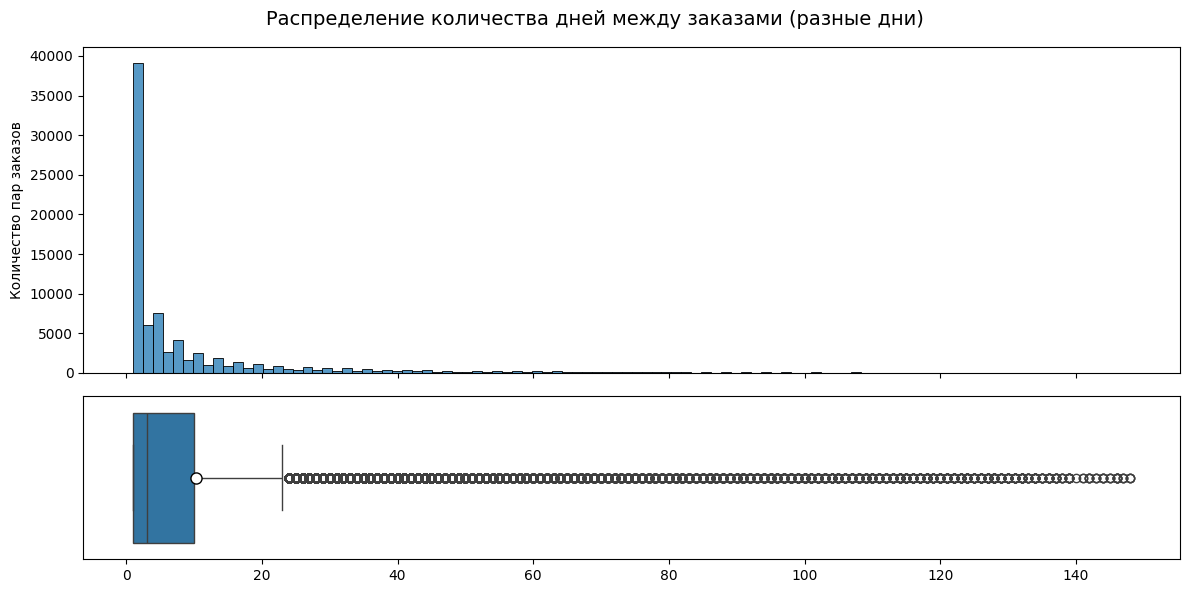

In [426]:
draw_double_diag(df[df['days_since_prev'] > 0],
                 "Распределение количества дней между заказами (разные дни)",
                 'days_since_prev',
                 None,
                 "Количество дней",
                 "Количество пар заказов",
                 kde=False,
                 bins=100
                 )


**Вывод:** Высокое значение повторных заказов в течение одного дня будет влиять на рассчитываемый показатель среднего количества дней между заказами. Стоит добавить еще один количественный признак - среднее количество дней между заказами, сделанными в разные дни.

### 2.5. Приведение типов столбцов

- Определим, можно ли уменьшить размерность числовых типов:

In [427]:
display(df.describe().loc[['max', 'min']])

,order_id,order_dt,order_ts,revenue,tickets_count,days_since_prev,event_id,revenue_rub
max,8653108.0,2024-10-31 00:00:00,2024-10-31 23:59:54,13784.26,47.0,148.0,592325.0,2627.00
min,1.0,2024-06-01 00:00:00,2024-06-01 00:00:42,0.02,1.0,0.0,4436.0,0.02


- Можно уменьшить разрядность столбца `tickets_count` до 8, а столбцов `order_id` и `event_id` - до 32.
- Также приведем к типу `category` категориальные столбцы.

In [428]:
# Преобразование типов столбцов
# df['order_id'] = df['order_id'].astype('int32')
# df['event_id'] = df['event_id'].astype('int32')
# df['tickets_count'] = df['tickets_count'].astype('int8')

df['days_since_prev'] = pd.to_numeric(df['days_since_prev'].astype('Int64'), downcast='integer')

df['order_id'] = pd.to_numeric(df['order_id'], downcast='integer')
df['event_id'] = pd.to_numeric(df['event_id'], downcast='integer')
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

df['event_type_main'] = df['event_type_main'].astype('category')
df['city_name'] = df['city_name'].astype('category')
df['region_name'] = df['region_name'].astype('category')
df['service_name'] = df['service_name'].astype('category')
# Проверка
df.info()

<class 'pandas.DataFrame'>
Index: 281658 entries, 285283 to 92210
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                281658 non-null  str           
 1   device_type_canonical  281658 non-null  str           
 2   order_id               281658 non-null  int32         
 3   order_dt               281658 non-null  datetime64[us]
 4   order_ts               281658 non-null  datetime64[us]
 5   currency_code          281658 non-null  str           
 6   revenue                281658 non-null  float64       
 7   tickets_count          281658 non-null  int8          
 8   days_since_prev        260285 non-null  Int16         
 9   event_id               281658 non-null  int32         
 10  event_name             281658 non-null  str           
 11  service_name           281658 non-null  category      
 12  event_type_main        281658 non-null  category      
 

In [429]:
display(Markdown(f'''
#### Выводы:
Были выполнены следующие преобразования:
- Приведение выручки к одной валюте - рублю.
- Проверка данных на ошибочные категориальные признаки. Таких признаков не найдено, для типа мероприятия присутствует значение-заглушка `другое`.
- Проверка данных на дубликаты. Были найдены дубликаты заказов в количестве {duplicates_count} шт. Они были удалены.
- Проверка данных на аномальные значения. Были обнаружены аномально высокие значения выручки, которые не являются ошибочными. Их количество составляет {anomalies_count}, 
или {anomalies_perc}% от исходных данных. Эти заказы также были удалены, чтобы не искажать статистику.
- Анализ распределения количества дней между заказами. Было установлено, что более половины заказов совершаются в один день с предыдущими. Предложено ввести 
дополнительный признак для анализа - количество дней между заказами, сделанными в разные дни.
- Всего было удалено {duplicates_count+anomalies_count} строк или {round((duplicates_count+anomalies_count) / initial_count * 100.0, 2)}%
- Оптимизация разрядности целочисленных столбцов и приведение категориальных столбцов к типу `category`.'''))


#### Выводы:
Были выполнены следующие преобразования:
- Приведение выручки к одной валюте - рублю.
- Проверка данных на ошибочные категориальные признаки. Таких признаков не найдено, для типа мероприятия присутствует значение-заглушка `другое`.
- Проверка данных на дубликаты. Были найдены дубликаты заказов в количестве 40 шт. Они были удалены.
- Проверка данных на аномальные значения. Были обнаружены аномально высокие значения выручки, которые не являются ошибочными. Их количество составляет 8913, 
или 3.07% от исходных данных. Эти заказы также были удалены, чтобы не искажать статистику.
- Анализ распределения количества дней между заказами. Было установлено, что более половины заказов совершаются в один день с предыдущими. Предложено ввести 
дополнительный признак для анализа - количество дней между заказами, сделанными в разные дни.
- Всего было удалено 8953 строк или 3.08%
- Оптимизация разрядности целочисленных столбцов и приведение категориальных столбцов к типу `category`.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Предобработка данных <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
 
<b>Нужно доработать ❌:</b>

* В задании это не указывается, но по умолчанию важным шагом предварительного анализа и предобработки является проверка на наличие дубликатов.
    
  
* В дальнейшем анализе мы будем задействовать 4 номинальных признака, из них сейчас проверен только один. При проверке признаков с большим количеством уникальных значений на неявные дубликаты стоит проверять в том числе самые редкие значения. Если они странно выглядят, отличаются от основного формата записи, значит дубликаты имеются, нужно изучить вопрос более подробно.
    

* После завершения предобработки необходимо зафиксировать итоговые выводы - кратко, что было проделано и какие решения приняты, сколько данных мы потеряли и сколько пойдет в дальнейший анализ, достаточно ли это. Потери и остаток лучше рассчитывать динамически.
    
</div>
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации 💡:</b> 
    
* Дубликаты могут быть в том числе и неполные, например, если заказ пользователя задублировался в системе, был создан в нескольких экземплярах с разным `order_id` и, возможно, даже с небольшой разницей во времени, за которое человек не успел бы вручную произвести еще одну покупку. Чтобы не искажать статистические расчеты, от таких наблюдений тоже важно избавляться. Но для начала нужно проверить их наличие - для этого необходимо проверить, есть ли дубликаты на подвыборке без `order_id` и `days_since_prev`. Если обнаружим их и примем решение удалить, то потребуется также пересчитать признак с количеством дней между заказами.
    

* Какое решение принято в отношении пропусков, почему имеено такое? Было бы не лишним убедиться, что пропуски имеются только в количестве дней между заказами у первых заказов пользователей, то есть что проблемы здесь нет. Это как раз и будет обоснованием.


* Снизить размерность типа для количественных показателей имеет смысл уже после проведения предобработки. Для смены числовых типов лучше использовать [to_numeric](https://pandas.pydata.org/docs/reference/api/pandas.to_numeric.html) с настройкой `downcast`, чтобы минимальная возможная точность определялась автоматически, и мы случайно бы не стерли вариативность (количество дней только заранее нужно перевести в `Int`, который, в отличие от `int`, дозволяет присутствие пропусков, а уже потом даункастить).
    
    Также, если признак состоит из повторяющихся категорий (в этом нужно убедиться), то ему можно назначить тип `category`.

    
* Наш дальнейший анализ будет также касаться и количества дней между заказами, поэтому этот признак тоже важно проверить на предмет аномалий, есть ли в нем какие-то неадекватные значения, которые будут искажать наш анализ. 
    
    
* Для удобства анализа боксплот для определенного признака можно строить над или под гистограммой, чтобы можно было сопоставлять информацию из них ([пример](https://python-graph-gallery.com/24-histogram-with-a-boxplot-on-top-seaborn/)). Можно даже создать пользовательскую функцию, которая будет принимать на вход признак и выводить для него сразу два типа визуализации в одном графике. Для лучшего ориентирования внутри графика стоит добавить сетку.


* При принятии решения относительно выбросов - оставляем или выбрасываем - стоит пояснять, во-первых, откуда они могли взяться, во-вторых, ввиду причины их возникновения, полезно ли будет их учитывание для целей нашего анализа. Сейчас не ясно, почему принято именно такое решение по работе с выбросами.


* Перед удалением строк сперва необходимо проверять, не слишком ли большой объем данных мы потеряем, допустимо ли это, или все же оптимальнее удалить сам признак.


* Для лучшей навигации по проекту было бы неплохо создать четкую последовательность действий, выделить тематические подразделы.

</div>


<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Дополнил проверку категориальных признаков, добавил анализ количества заказов и вывод. Также мелкие улучшения и исправления ошибок по коду и графикам. Выделены тематические подразделы.
</div>

## 3. Построение профилей пользователей

- Вычисляем параметры профиля:

In [430]:
# Группируем датасет по user_id (он уже отсортирован ранее)
df_grouped = df.groupby('user_id')

# Вычисляем переиспользуемые параметры
first_orders = df_grouped.first()
last_orders = df_grouped.last()
orders_counts = df_grouped['order_id'].count()

# Формируем датафрейм с профилями пользователей
df_user_profile = pd.DataFrame({'first_order_dt': first_orders['order_dt'],
                                'last_order_dt': last_orders['order_dt'],
                                'first_order_device': first_orders['device_type_canonical'],
                                'first_order_region': first_orders['region_name'],
                                'first_order_service_name': first_orders['service_name'],
                                'first_order_genre': first_orders['event_type_main'],
                                'orders_count': orders_counts,
                                'avg_revenue_rub': df_grouped['revenue_rub'].mean(),
                                'avg_tickets_count': df_grouped['tickets_count'].mean(),
                                'avg_interval': df_grouped['days_since_prev'].mean()}) #((last_orders['order_dt'] - first_orders['order_dt']) / (orders_counts - 1)).dt.days})

# Дополнительные флаги
df_user_profile['is_two'] = df_user_profile['orders_count'] >= 2
df_user_profile['is_five'] = df_user_profile['orders_count'] >= 5

display(df_user_profile.info())
display(df_user_profile.head())

<class 'pandas.DataFrame'>
Index: 21694 entries, 0002849b70a3ce2 to ffff00725179321
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   first_order_dt            21694 non-null  datetime64[us]
 1   last_order_dt             21694 non-null  datetime64[us]
 2   first_order_device        21694 non-null  str           
 3   first_order_region        21694 non-null  category      
 4   first_order_service_name  21694 non-null  category      
 5   first_order_genre         21694 non-null  category      
 6   orders_count              21694 non-null  int64         
 7   avg_revenue_rub           21694 non-null  float64       
 8   avg_tickets_count         21694 non-null  float64       
 9   avg_interval              13448 non-null  Float64       
 10  is_two                    21694 non-null  bool          
 11  is_five                   21694 non-null  bool          
dtypes: Float64

None

,first_order_dt,last_order_dt,first_order_device,first_order_region,first_order_service_name,first_order_genre,orders_count,avg_revenue_rub,avg_tickets_count,avg_interval,is_two,is_five
user_id,,,,,,,,,,,,
0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.940000,4.000000,<NA>,False,False
0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.010000,3.000000,75.0,True,False
000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.213333,2.666667,51.0,True,False
00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.830000,4.000000,<NA>,False,False
000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.310000,1.500000,16.0,True,False


<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Создание профиля пользователя <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">

<b>Отлично ✅:</b> Хорошо, что, ввиду использования агрегата `first`, не забываешь про сортировку заказов!

</div>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
 
<b>Нужно доработать ❌:</b> 

* Сейчас ты сортируешь заказы по дате, но ведь пользователь мог совершать несколько заказов в день. Сейчас такие случаи у тебя расположились случайно внутри дня. Чтобы было корректно, сортировать необходимо по времени заказа.
    
    
* Обрати внимание, что интвалов между заказами меньше, чем самих заказов. Также заметь, что в случае одного заказа - когда первая дата совпадает с последней - у тебя получаются нули, из-за чего такие клиенты перемешиваются с теми, кто совершил несколько заказов в один день.

</div>

<div style="border-radius: 10px" class="alert alert-warning">

<b>Рекомендации💡:</b>

* Агрегацию оптимальнее было бы провести черезе удобный метод [agg](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.agg.html).


* Есть довольно удобный метод [assign](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.assign.html), позволяющий дополнять таблицу новыми рассчитанными столбцами.

    Тогда создание всего профиля можно будет записать красивым и удобным по структуре кодом.
    
    <details> <summary> <span style='color:blue' > Развернуть подробнее. </span> </summary>
    
    ```python
    profiles = (df
            # В начале сортируем данные по дате совершения заказа, что найти первые признаки:
            .sort_values(by='order_ts')
            # Затем группируем по номеру пользователя и агрегируем данные:
            .groupby('user_id')
            .agg(
                # Находим первую и последнюю даты заказа:
                first_order_dt=('order_dt','min'),
                last_order_dt=('order_dt','max'),
                # Находим устройства, регион, название билетного партнера и жанр мероприятия первого заказа:
                first_device=('device_type_canonical','first'),
                first_region_name=('region_name','first'),
                first_service_name=('service_name','first'),
                first_event_type=('event_type_main','first'),
                # Подсчитваем количество заказов:
                total_orders=('order_id','nunique'),
                # Считаем статистику по заказам: средняя стоимость заказа, среднее количество билетов:
                avg_revenue_rub=('revenue_rub','mean'),
                avg_tickets_count=('tickets_count','mean'),
                # Считаем среднее количество дней между покупками:
                avg_days_since_prev=('days_since_prev','mean')
            )
            # Создаем два признака: совершил ли пользователь 2 / 5 и более заказов:
            .assign(
                is_two = lambda x: x['total_orders'] >= 2,
                is_five = lambda x: x['total_orders'] >= 5
            )
            .reset_index()
    )
    ```

    Таким же образом можно задать округление при необходимости.
    
    </details>

</div>

<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Исправил замечания. Спасибо за пример кода с использованием `assign`!
</div>

- Рассчитаем агрегатные показатели по профилям пользователей:

In [431]:
print("Число пользователей:", len(df_user_profile))
print(f"Средняя выручка с заказа: {df_user_profile['avg_revenue_rub'].mean():.2f}р.")
print(f"Доля пользователей с 2 и более заказами: {df_user_profile['is_two'].mean():.2f}")
print(f"Доля пользователей с 5 и более заказами: {df_user_profile['is_five'].mean():.2f}")

Число пользователей: 21694
Средняя выручка с заказа: 550.85р.
Доля пользователей с 2 и более заказами: 0.62
Доля пользователей с 5 и более заказами: 0.29


- Также рассчитаем статистические показатели по числовым параметрам:

In [432]:
# Статистические показатели
display(df_user_profile[['orders_count', 'avg_tickets_count', 'avg_interval']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,orders_count,avg_tickets_count,avg_interval
count,21694.000000,21694.000000,13448.0
mean,12.983221,2.745788,15.93077
std,119.703141,0.914597,22.383412
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,1.0
50%,2.000000,2.750000,8.0
75%,5.000000,3.090909,20.5
90%,15.000000,4.000000,41.5
95%,31.000000,4.000000,61.5
99%,150.070000,5.000000,113.0


В поле `orders_count` присутствуют выбросы - аномально большие значения. Крайне маловероятно, чтобы реальный пользователь мог разместить почти 10000 заказов - скорее всего, это ошибка, которая, тем не менее, будет сильно искажать статистику. Количество таких пользователей невелико - если отфильтровать данные по 99 процентилю, все они будут удалены.

In [433]:
users_count_before_filter = len(df_user_profile)
returnability_before_filter = df_user_profile['is_two'].mean()
avg_revenue_before_filter = df_user_profile['avg_revenue_rub'].mean()

# Отфильтруем профили по 99 процентилю orders_count
percentile_99 = df_user_profile['orders_count'].quantile(0.99)
df_user_profile = df_user_profile[df_user_profile['orders_count'] <= percentile_99]
deleted_count = users_count_before_filter - len(df_user_profile)

print(f"Было удалено {deleted_count} строк ({deleted_count / users_count_before_filter * 100:.2f}%).")
print(f"Количество оставшихся пользователей: {len(df_user_profile)}")
print(f"Изменение доли возвращающихся пользователей: до: {returnability_before_filter:.2f}, после: {df_user_profile['is_two'].mean():.2f}")
print(f"Изменение средней выручки: до: {avg_revenue_before_filter:.2f}, после: {df_user_profile['avg_revenue_rub'].mean():.2f}")

Было удалено 217 строк (1.00%).
Количество оставшихся пользователей: 21477
Изменение доли возвращающихся пользователей: до: 0.62, после: 0.61
Изменение средней выручки: до: 550.85, после: 551.12


- Обновленные статистические показатели:

In [434]:
# Статистические показатели
display(df_user_profile[['orders_count', 'avg_tickets_count', 'avg_interval']].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

,orders_count,avg_tickets_count,avg_interval
count,21477.000000,21477.000000,13231.0
mean,6.400428,2.745964,16.184465
std,13.965541,0.919065,22.477649
min,1.000000,1.000000,0.0
25%,1.000000,2.000000,1.3426
50%,2.000000,2.750000,8.411765
75%,5.000000,3.111111,21.0
90%,14.000000,4.000000,42.0
95%,26.000000,4.000000,62.0
99%,77.240000,5.000000,113.7


**Вывод:** 
- В результате анализа построенных профилей пользователей оказалось, что менее 1% пользователей совершили аномально высокое количество заказов. 
- По всей вероятности, эти данные являются ошибочными. Во избежание их влияния на дальнейший анализ они были удалены. 
- Другие числовые параметры являются вполне правдоподобными, поэтому по ним фильтрация не проводилась.
- В результате удаления выбросов доля вернувшихся пользователей и средняя выручка изменились незначительно.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Создание профиля пользователя <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">

<b>Отлично ✅:</b> Выполнены все необходимые шаги!

</div>

<div style="border-radius: 10px" class="alert alert-block alert-danger">
 
<b>Нужно доработать ❌:</b> Не хватает резюмирующих выводов.
</div>

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* Решение по выбросам пояснено поверхностно. Почему данне наблюдения мы не берем дальше с собой в анализ? Почему по другим признакам фильтрация не требуется?
    
    
* Было бы не лишним также проверить, насколько изменились показатели возвращаемости и средней выручки после фильтрации.


</div>


<div style="border-radius: 10px" class="alert alert-info">
<b>Комментарий А.Т.</b><br>
Дополнил проверкой изменения возвращаемости и средней выручки. Добавил вывод.
</div>

## 4. Исследовательский анализ данных

На данном этапе стоит задача исследовать признаки, влияющие на возврат пользователей, то есть совершение ими повторного заказа.

### 4.1. Исследование признаков первого заказа

- Построим датасеты с сегментацией данных по признакам первого заказа и вычислением доли пользователей, сделавших более одного заказа: 

In [435]:
def segment_counts(col_name):
    rv_df = pd.DataFrame({"quantity": df_user_profile[col_name].value_counts(),
                          "ratio": df_user_profile[col_name].value_counts() / len(df_user_profile),
                          "return_ratio": df_user_profile.groupby(by=col_name)['is_two'].mean()})
    display(rv_df.sort_values(by="quantity", ascending=False).head(10).style.background_gradient(cmap='viridis'))
    return rv_df

# Количество и доля пользователей по типу мероприятия
df_genre_segments = segment_counts('first_order_genre')

# Количество и доля пользователей по типу устройства
df_device_segments = segment_counts('first_order_device')

# Количество и доля пользователей по региону
df_region_segments = segment_counts('first_order_region')

# Количество и доля пользователей по билетному оператору
df_service_segments = segment_counts('first_order_service_name')

,quantity,ratio,return_ratio
first_order_genre,,,
концерты,9598,0.446897,0.617733
другое,5224,0.243237,0.594372
театр,4260,0.198352,0.634977
стендап,1118,0.052056,0.609123
спорт,765,0.035619,0.549020
выставки,415,0.019323,0.643373
ёлки,97,0.004516,0.567010


,quantity,ratio,return_ratio
first_order_device,,,
mobile,17799,0.828747,0.608012
desktop,3678,0.171253,0.636215


,quantity,ratio,return_ratio
first_order_region,,,
Каменевский регион,6975,0.324766,0.619211
Североярская область,3785,0.176235,0.640687
Широковская область,1234,0.057457,0.645057
Озернинский край,678,0.031569,0.551622
Малиновоярский округ,527,0.024538,0.557875
Шанырский регион,465,0.021651,0.694624
Светополянский округ,461,0.021465,0.657267
Травяная область,461,0.021465,0.616052
Речиновская область,445,0.020720,0.638202


,quantity,ratio,return_ratio
first_order_service_name,,,
Билеты без проблем,4968,0.231317,0.597625
Мой билет,2985,0.138986,0.607370
Лови билет!,2802,0.130465,0.611349
Билеты в руки,2549,0.118685,0.629659
Облачко,2198,0.102342,0.613740
Весь в билетах,1291,0.060111,0.628970
Лучшие билеты,1183,0.055082,0.614539
Прачечная,586,0.027285,0.626280
Край билетов,460,0.021418,0.654348


Распределение пользователей по сегментам неравномерно - по каждому из признаков есть сегменты, являющиеся лидерами по количеству пользователей. 
- Больше всего пользователей впервые приобрели билет на концерты (44.7%) и в театр (19.8%). На втором месте находится категория `другое` (24.3%).
- 82.1% пользователей приобрели первый билет через мобильное устройство.
- Среди регионов лидерами являются Каменевский регион и Североярская область (32.4% и 17.6% соответственно)
- Среди билетных операторов лидируют 5 операторов с суммарной долей 49%

Построим столбчатые диаграммы доли возвращающихся пользователей по всем показателям и сегментам:

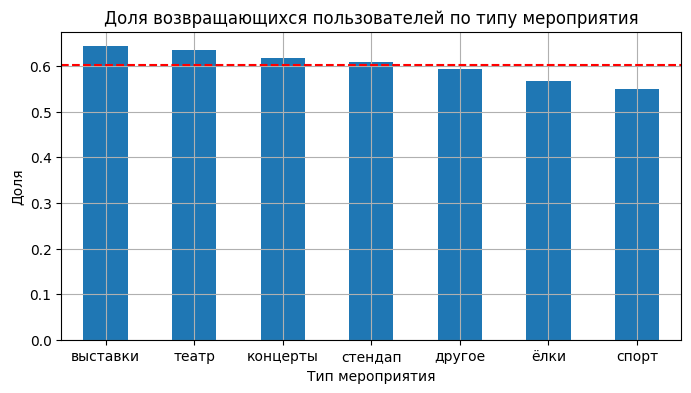

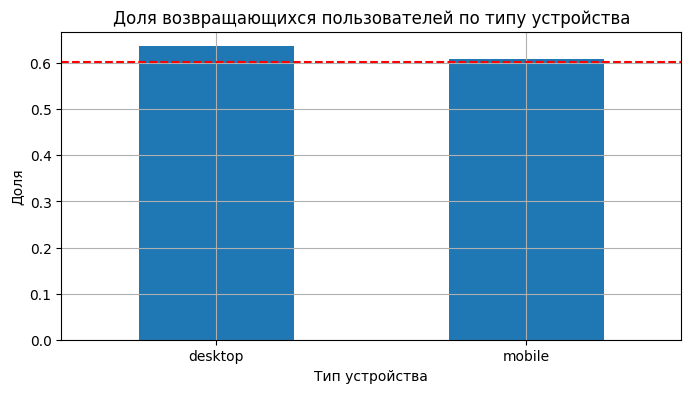

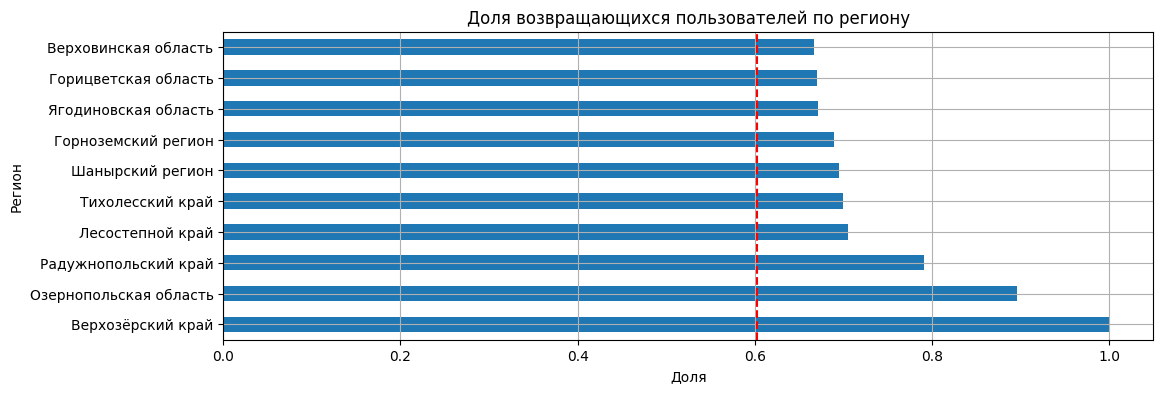

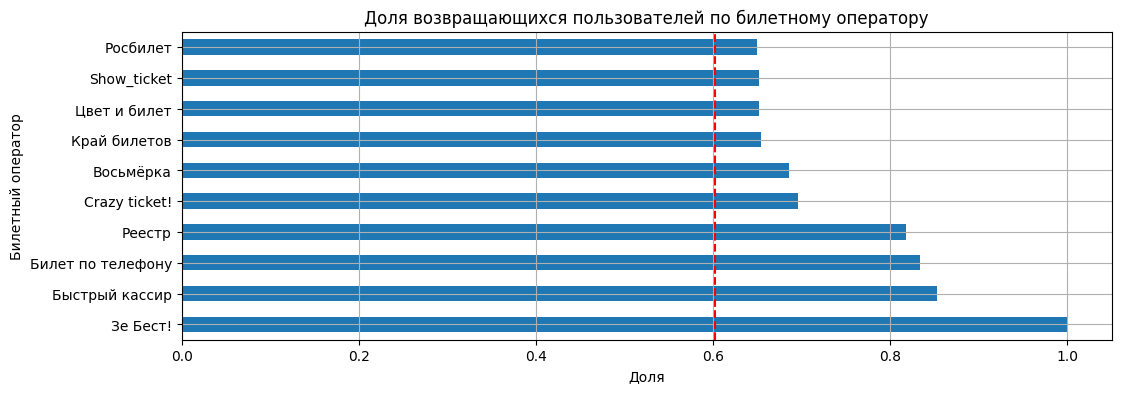

In [436]:
def draw_barplot(series, title, xlabel, ylabel, rot=0, vertical=True, mean=None):
    series.sort_values(ascending=False).head(10).plot(
        title=title,
        kind='bar' if vertical else 'barh',
        figsize=(8, 4) if vertical else (12, 4),
        xlabel=xlabel if vertical else ylabel,
        ylabel=ylabel if vertical else xlabel,
        grid=True,
        rot=rot)
    
    if mean != None:
        if vertical:
            plt.axhline(mean, color='red', linestyle='--')
        else:
            plt.axvline(mean, color='red', linestyle='--')
        plt.show()

mean = df_genre_segments['return_ratio'].mean()
draw_barplot(df_genre_segments['return_ratio'], "Доля возвращающихся пользователей по типу мероприятия", "Тип мероприятия", "Доля", mean=mean)
draw_barplot(df_device_segments['return_ratio'], "Доля возвращающихся пользователей по типу устройства", "Тип устройства", "Доля", mean=mean)
draw_barplot(df_region_segments['return_ratio'], "Доля возвращающихся пользователей по региону", "Регион", "Доля", vertical=False, mean=mean)
draw_barplot(df_service_segments['return_ratio'], "Доля возвращающихся пользователей по билетному оператору", "Билетный оператор", "Доля", vertical=False, mean=mean)

- Более других делают повторный заказ пользователи, у которых первый тип мероприятия - **выставка, театр, концерт или стендап**. **Гипотеза о том, что чаще возвращаются пользователи с первым заказом на спортивные мероприятия, оказывается неверной**

Среди долей возвратов по регионам присутствуют подозрительные данные (доля возвращающихся пользователей около 1). Возможно, данные по ним нерелевантны из-за низкого количества клиентов. Сопоставим для них долю возвратов с количеством клиентов:

In [437]:
display(df_region_segments.sort_values(by="return_ratio", ascending=False).head(15).style.background_gradient(cmap='viridis'))

,quantity,ratio,return_ratio
first_order_region,,,
Верхозёрский край,1,0.000047,1.000000
Озернопольская область,29,0.001350,0.896552
Радужнопольский край,24,0.001117,0.791667
Лесостепной край,61,0.002840,0.704918
Тихолесский край,10,0.000466,0.700000
Шанырский регион,465,0.021651,0.694624
Горноземский регион,29,0.001350,0.689655
Ягодиновская область,64,0.002980,0.671875
Горицветская область,249,0.011594,0.670683


Видно, что регионы с наибольшей долей возвратов содержат не более 100 клиентов с первым заказом в этом регионе (десятые доли процента), поэтому эти сведения нерелевантны. Построим диаграмму доли возвратов, отбросив регионы с долей клиентов меньше 1% и добавив для сравнения долю пользователей с первым заказом в этом регионе:

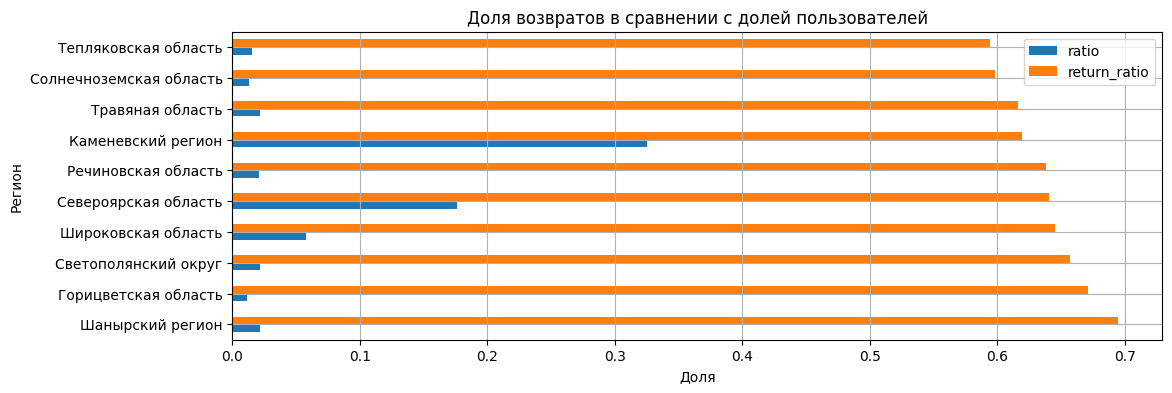

In [438]:
df_region_segments[df_region_segments['ratio'] >= 0.01][['ratio', 'return_ratio']].sort_values(by='return_ratio', ascending=False).head(10).plot(
    title="Доля возвратов в сравнении с долей пользователей",
    kind='barh',
    figsize=(12, 4),
    xlabel="Доля",
    ylabel="Регион",
    grid=True)
plt.show()

- Видно, что **нет прямой зависимости между количеством пользователей в регионе и количеством возвратов в нем**.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ сегментов пользователей <a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Здорово, что функционализируешь выполнение повторяющихся действий! Это облегчает код и уменьшает влияние человеческого фактора.
 
</div>
   

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* Можно также зациклить выполнение определенного шаблона действий, чтобы потом уже только анализировать.


* В случае вывода неполного набора сегментов стоит указать, какой процент от выборки они составляют, чтобы было понимание, насколько большая часть данных осталась за пределами нашего обзора.


* Ввиду различия размерности групп линия на графике должна задавать возвращаемость в выборке, а не среднее между возвращаемостями по группам.
    
 
* В выводах по первым двум частям было бы неплохо также попробовать предположить, почему мы могли получить то или иное распределение по сегментам и определенный уровень возвращаемости, почему показатели оказались именно такими. Это может быть полезно в плане развития стратегий по привлечению новых пользователей.
    
    
* С выводами по второй гипотезе стоит быть осторожнее. Действительно, важно учитывать размерность групп при сравнении долей! В менее популярных группах 1 дополнительный пользователь имеет больший вес, а потому показатель возвращаемости у таких категорий больше подвержен колебаниям, менее стабилен. Например, если бы у нас в группу с остальными регионами попало только два региона с одним пользователем, в одном вернулось 100%, в другом 0%, среднее 50%, показательно ли это? Чтобы сделать более осознанный вывод, можно, к примеру, построить скаттерплот с отображением размера региона и возвращаемости в нем, тогда будет видно всю картину в данных и можно будет сказать, что судя по относительно крупным регионам, в стабильности которых мы более менее уверены, такой зависимости не наблюдается. Логически мы ее подразумеваем - в крупных регионах больше инфраструктуры, больше мероприятий, что способствует возвращаемости, но статистических оснований подтвердить это у нас сейчас недостаточно.
    
    Но вообще, чтобы наверняка убедиться в том, что возвращаемость в непопулярных группах ниже, и это не случайное колебание, следует провести статистический тест, оценить значимость различий. Это будет изучаться в дальнейшем на курсе, там есть довольно много нюансов.  


* Каков итоговый вывод по анализу сегментов? Какие инсайты мы получили?

    
</div>

### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

- Исследуем соотношение средней выручки c долями вернувшихся и не вернувшихся пользователей:

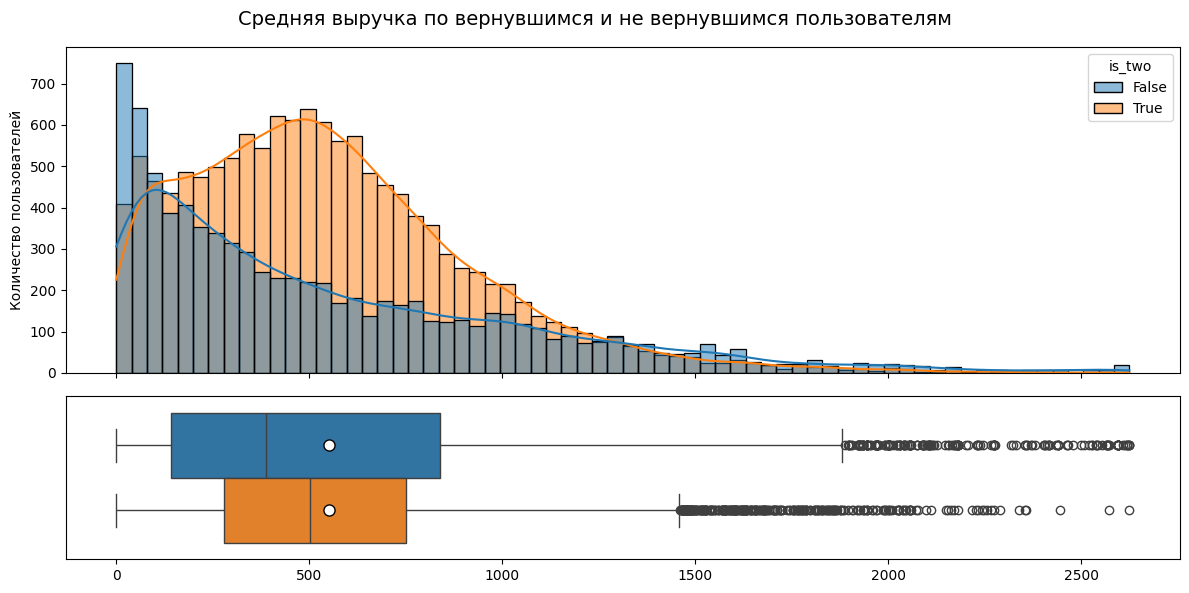

Статистика по вернувшимся пользователям:


count    13162.000000
mean       550.821249
std        367.454966
min          0.352000
25%        278.365312
50%        503.061822
75%        750.925000
max       2624.814609
Name: avg_revenue_rub, dtype: float64

Статистика по одноразовым пользователям:


count    8315.000000
mean      551.598120
std       516.807509
min         0.070000
25%       141.130000
50%       388.560000
75%       838.325000
max      2624.814609
Name: avg_revenue_rub, dtype: float64

In [439]:
draw_double_diag(df_user_profile,
                 'Средняя выручка по вернувшимся и не вернувшимся пользователям',
                 'avg_revenue_rub',
                 'is_two',
                 'Средняя выручка, р.',
                 'Количество пользователей')

print("Статистика по вернувшимся пользователям:")
display(df_user_profile[df_user_profile['is_two']]['avg_revenue_rub'].describe())
print("Статистика по одноразовым пользователям:")
display(df_user_profile[~(df_user_profile['is_two'])]['avg_revenue_rub'].describe())


- Оба распределения асимметричны, у распределения выручки среди вернувшихся клиентов правый хвост короче, пик смещен вправо.
- Максимальное количество вернувшихся клиентов совершает совершает покупки в среднем на 503 р., одноразовых - примерно на 100 р.
- Медианная выручка по одноразовым пользователям ниже, чем по вернувшимся, однако средние значения находятся на одном уровне.
- Выручка от одноразовых пользователей имеет больший межквартильный интервал и концентрируется в диапазоне 141-839 р.
- Выручка от вернувшихся пользователей сконцентрирована в диапазоне 278-751 р.

Исследуем подробнее статистику по возвращающимся пользователям в двух группах:
- совершившие 2–4 заказа;
- совершившие 5 и более заказов;

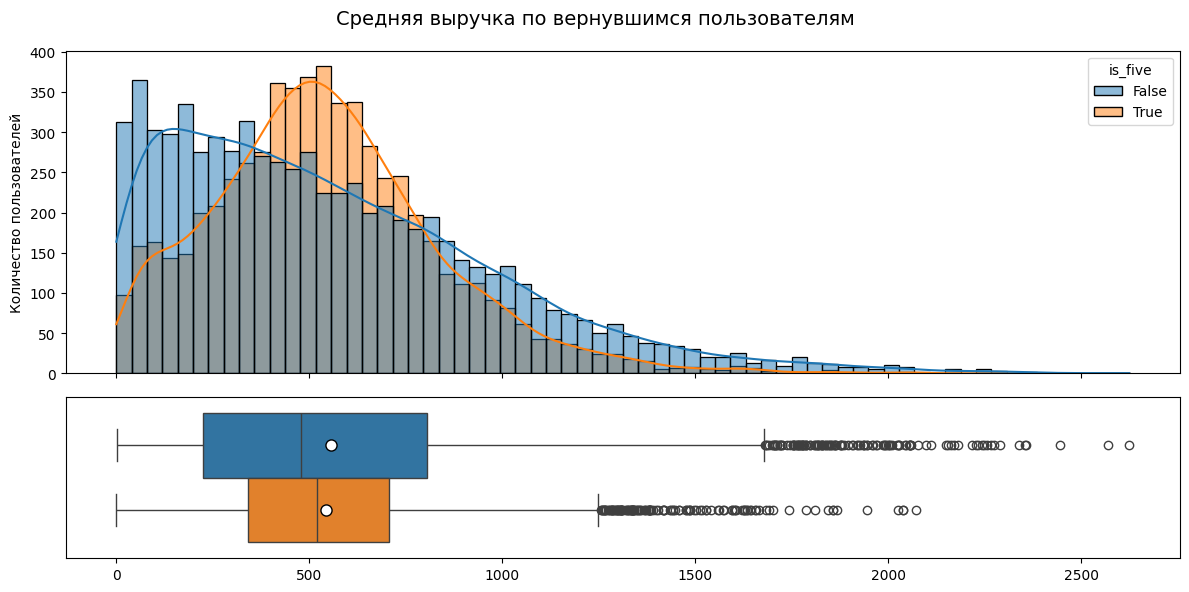

Статистика по пользователям с 5 и более заказами:


count    6043.000000
mean      543.649900
std       296.120909
min         0.352000
25%       341.254806
50%       520.948400
75%       707.371693
max      2071.622857
Name: avg_revenue_rub, dtype: float64

Статистика по пользователям с 2-4 заказами:


count    7119.000000
mean      556.908686
std       418.499017
min         2.416667
25%       224.095833
50%       477.600853
75%       806.020000
max      2624.814609
Name: avg_revenue_rub, dtype: float64

In [440]:
df_users_two = df_user_profile[df_user_profile['is_two']]

draw_double_diag(df_users_two,
                 'Средняя выручка по вернувшимся пользователям',
                 'avg_revenue_rub',
                 'is_five',
                 'Средняя выручка, р.',
                 'Количество пользователей')

print("Статистика по пользователям с 5 и более заказами:")
display(df_users_two[df_users_two['is_five']]['avg_revenue_rub'].describe())
print("Статистика по пользователям с 2-4 заказами:")
display(df_users_two[~(df_users_two['is_five'])]['avg_revenue_rub'].describe())

- Медиана выручки от пользователей, сделавших 2-4 заказа меньше, чем медиана выручки от пользователей с 5 и более заказами (477 против 521 р.)
- Среднее значение выручки наоборот, чуть больше у пользователей с 2-4 заказами (557 против 544 р.)

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ взаимосвязи средней выручки и числа заказов <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> 
    
* С этой задачей в целлом справились! 

    
* Благодаря раскрашиванию по группам средствами `seaborn` автоматически нормализовался и размер бинов. Если бы мы строили отдельные графики и накладывали их друг на друга, то настраивание единого размера бинов пришлось бы делать вручную.
 
</div>
    
    
<div style="border-radius: 10px" class="alert alert-block alert-danger">
    
<b>Нужно доработать ❌:</b> Не хватает нормализации высоты. Все же подвыборки у нас разного размера.
 
</div>

<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b>  

* Выводы крайне поверхностные, по сути не выявлено ничего полезного для бизнеса. В выводах стоит выделить сегменты концентрации - резюмировать информацию с графиков в более понятные лаконичные диапазоны, при этом, в том числе обратить внимание на хвосты. Затем попробовать подумать, что для нас могут значить результаты, почему они могли получиться именно такими, что это говорит о клиентах, об их стабильности? Это может быть полезно в плане развития стратегий по работе с той или иной категорией пользователей.


* Каков итоговый вывод по анализу выручки? Какие инсайты мы получили?
    
</div>

<br><br>
- Проанализируем влияние среднего количества билетов в заказе на вероятность повторной покупки.
Разделим пользователей на категории по среднему количеству билетов в заказе:

,Количество,Доля вернувшихся
avg_tickets_count,,
2-3,9822,0.742415
3-5,5349,0.628155
1-2,4784,0.477843
5 и более,194,0.324742


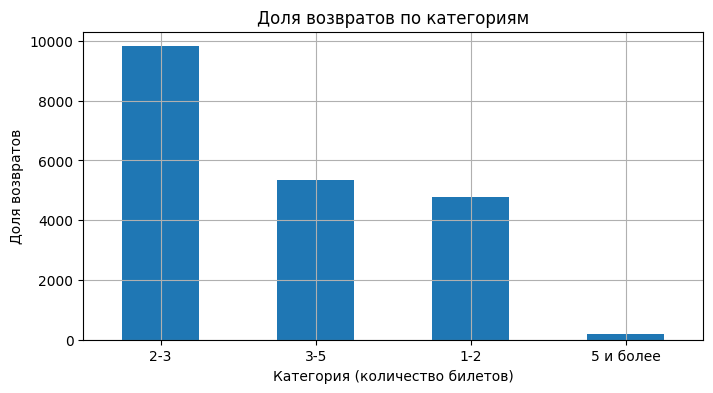

In [441]:
df_tc_cat = pd.cut(df_user_profile['avg_tickets_count'], 
                   bins=[1, 2, 3, 5, np.inf], 
                   labels=["1-2", "2-3", "3-5", "5 и более"]).value_counts()
df_tc_ret_cat = pd.cut(df_user_profile[df_user_profile['is_two']]['avg_tickets_count'], 
                       bins=[1, 2, 3, 5, np.inf], 
                       labels=["1-2", "2-3", "3-5", "5 и более"]).value_counts() / df_tc_cat

draw_barplot(df_tc_cat.sort_values(ascending=False),
              "Количество пользователей по категориям",
              "Категория (количество билетов)",
              "Количество пользователей")

draw_barplot(df_tc_ret_cat.sort_values(ascending=False),
             "Доля возвратов по категориям",
             "Категория (количество билетов)",
             "Доля возвратов")

display(pd.DataFrame({"Количество": df_tc_cat,
                      "Доля вернувшихся": df_tc_ret_cat}).style.background_gradient(cmap='viridis'))

- Пользователи распределены по категориям неравномерно: больше всего пользователей приобрели в среднем от 2 до 3 билетов, меньше всего - 5 и более.
- Доля возвращающихся пользователей в категории растет вместе с общим количеством пользователей в ней, но зависимость доли возвратов от количества пользователей нелинейная.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ взаимосвязи количества билетов в заказе и возвращаемости <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b>

* Здесь тоже в целом окей, справились! 


* Здорово, что используешь удобный метод [сut](https://pandas.pydata.org/docs/reference/api/pandas.cut.html).
 
</div>
<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b>

* Необходимо только пересмотреть настройки параметров, сейчас у тебя первый сегмент включает обе границы, а последний не включает их вовсе. Сейчас по всему диапазону у нас есть фиксированное ограничение снизу, и нет ограничения сверху, по такой же логике стоит формировать и сегменты - включать левую границу и исключать правую.


* Столбики на графике стоит расположить в логическом порядке.


* Опять же, это едва ли можно назвать аналитикой. В выводах было бы неплохо предположить, что за типы клиентов попали в каждую из групп, почему получились именно такие результаты по возвращаемости? Чем данная информация интересна бизнесу? Опять же, это может быть полезно в плане развития стратегий по рабое с разными типами пользователей.

</div>

### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки
Исследуем влияние следующих параметров на вероятность возврата пользователей:
- день недели первой покупки;
- время с момента первой покупки — лайфтайм;
- средний интервал между покупками пользователей с повторными заказами.

,Количество,Доля вернувшихся
first_order_dt,,
Суббота,3293,0.627999
Пятница,3231,0.598886
Вторник,3147,0.617413
Четверг,3099,0.595031
Среда,3048,0.621719
Понедельник,2902,0.626465
Воскресенье,2757,0.601741


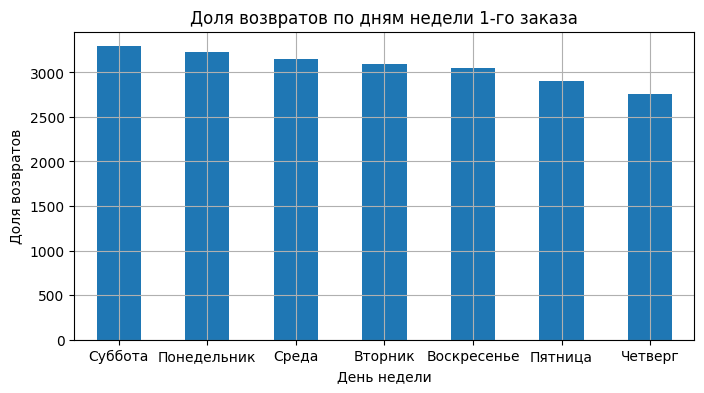

In [ ]:
# Дополним профиль новым параметром - день недели первого заказа
df_user_profile['first_order_dow'] = df_user_profile['first_order_dt'].dt.day_name()

df_1day_cat = df_user_profile['first_order_dt'].dt.day_of_week.value_counts().sort_values(ascending=False)
df_1day_ret_cat = (df_user_profile[df_user_profile['is_two']]['first_order_dt'].dt.day_of_week.value_counts() / df_1day_cat).sort_values(ascending=False)
days = {
    0: "Понедельник",
    1: "Вторник",
    2: "Среда",
    3: "Четверг",
    4: "Пятница",
    5: "Суббота",
    6: "Воскресенье"
}

df_1day_cat.index = df_1day_cat.index.map(days)
df_1day_ret_cat.index = df_1day_ret_cat.index.map(days)

draw_barplot(df_1day_cat.sort_values(ascending=False), 
             "Количество пользователей по дням недели 1-го заказа", 
             "День недели", 
             "Количество пользователей")

draw_barplot(df_1day_ret_cat.sort_values(ascending=False),
             "Доля возвратов по дням недели 1-го заказа",
             "День недели",
             "Доля возвратов",)

display(pd.DataFrame({"Количество": df_1day_cat,
                      "Доля вернувшихся": df_1day_ret_cat})
                      .sort_values(by="Количество", ascending=False)
                      .style
                      .background_gradient(cmap='viridis'))

- Наиболее часто первый заказ совершается накануне и в первый день выходных - с четверга по субботу, а также - во вторник, который является днем скидок в некоторых сетях кинотеатров.
- Чаще всего возвращаются пользователи, сделавшие первый заказ в субботу и понедельник, однако доля вернувшихся пользователей в зависимости от дня первой покупки различается незначительно, и вполне вероятно, что отличия являются случайными.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ возвращаемости по дням недели  <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> Здесь все корректно. Различия по дням недели все же наблюдаются, хотя и не очень заметные. Чтобы судить более однозначно, было бы неплохо сопроводить сравнение оценкой статистической значимости. Это будет изучаться далее на курсе.

</div>
<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации 💡:</b>

* Есть метод, который позволяет сразу вытаскивать наименования: `.dt.day_name()`.


* Столбики на графике стоит расположить в логическом порядке.


* В выводах было бы неплохо также предположить, почему в топ и антитоп (которые все-таки создается, хотя и на так явно) выбиваются определенные дни недели? Какие суждения относительно этого можно выстроить? Чем отличаются пользователи, формирующие заказ в тот или иной день?


</div>

Исследуем зависимость возвратов от среднего интервала между заказами, а также от времени жизни (интервалом между датами последнего и первого заказа) в категориях пользователей `"2-4 заказа"` и `"5 и более заказов"`:

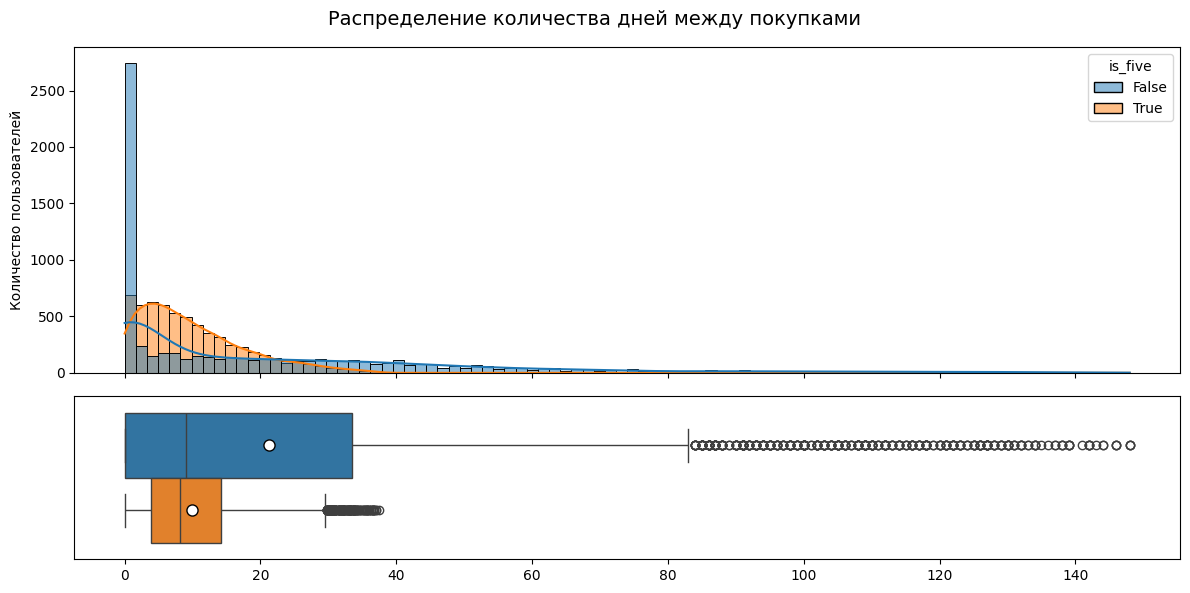

Статистика по пользователям с 2-4 заказами:


count       7119.0
mean     21.234349
std      28.369258
min            0.0
25%            0.0
50%            9.0
75%           33.5
max          148.0
Name: avg_interval, dtype: Float64

Статистика по пользователям с 5 и более заказами:


count       6043.0
mean      9.901096
std       7.798401
min            0.0
25%       3.884034
50%       8.111111
75%      14.166667
max           37.5
Name: avg_interval, dtype: Float64

In [443]:
df_returned = df_user_profile[df_user_profile['is_two']]

draw_double_diag(df_returned,
                 "Распределение количества дней между покупками",
                 'avg_interval',
                 'is_five',
                 "Количество дней",
                 "Количество пользователей")

print("Статистика по пользователям с 2-4 заказами:")
display(df_returned[~(df_returned['is_five'])]['avg_interval'].describe())
print("Статистика по пользователям с 5 и более заказами:")
display(df_returned[df_returned['is_five']]['avg_interval'].describe())

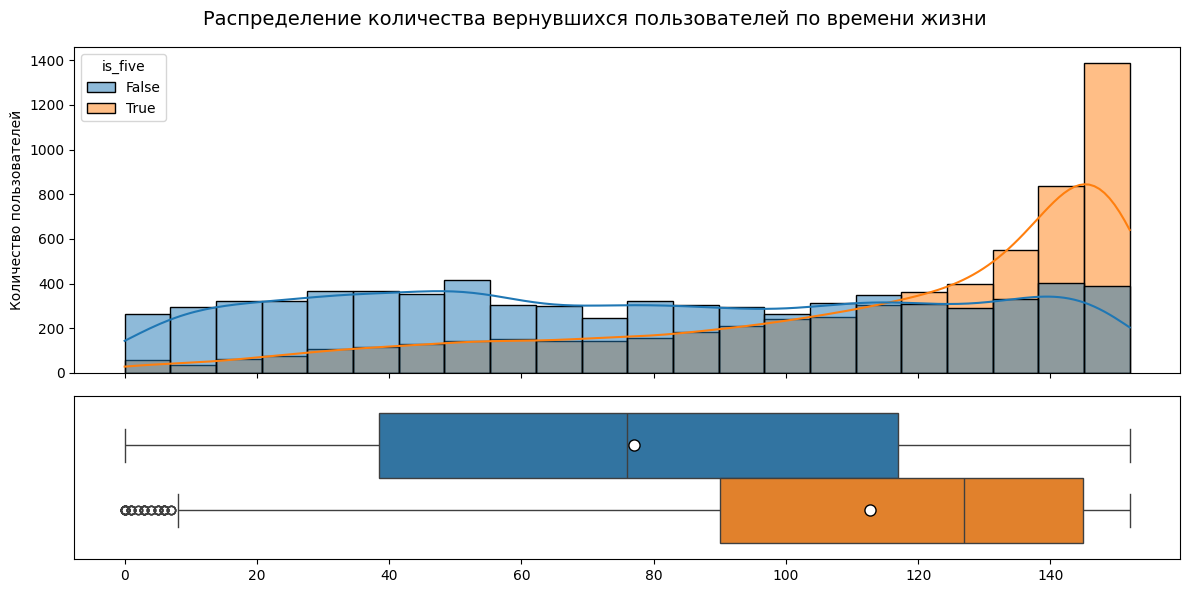

In [444]:
df_returned['lifetime'] = (df_returned['last_order_dt'].max() - df_returned['first_order_dt']).dt.days

draw_double_diag(df_returned,
                 "Распределение количества вернувшихся пользователей по времени жизни",
                 'lifetime',
                 'is_five',
                 "Дата",
                 "Количество пользователей")

- Наибольшее количество пользователе с 2-4 заказами совершают свои заказы в течение одного дня, однако присутствуют в небольшом количестве и выбросы до 74 дней, из-за чего среднее (12.3 дня) сильно отличается от медианы (5 дней). 
- У пользователей с 5 и более заказами распределение имеет другой характер - оно сконцентрировано в диапазоне 3-12 дней, максимальные выбросы не превышают 30 дней, среднее (8.2 дня) близко к медиане (7 дней).
- Распределение по времени, прошедшему с даты первого заказа, пользователей с 2-4 заказами близко к равномерному, а пользователей с 5 и более заказами монотонно возрастает, причем резкий рост начинается после 120 дней. Это согласуется с предыдущим распределением, так как большинство пользователей с 2-4 заказами делают их в один день, а у постоянных пользователей интервал между заказами больше и, соответственно, для размещения 5 и более заказов требуется больше времени.

**Вывод:**<br>
Совершение двух и более заказов в течение одного дня совсем не говорит о том, что пользователь еще вернется. Если интервал между заказами от 3 до 12 дней, велика вероятность, что такой пользователь станет постоянным (сделает 5 и более заказов). Но при увеличении интервала более 25-30 дней такой пользователь, скорее всего, не станет постоянным и не сделает более 2-4 заказов.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ возвращаемости по количеству дней между заказами <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b> По расчетам все верно!

</div>

    
<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации 💡:</b> Логично, что на ограниченном промежутке времени у клиента с большим количеством заказов интервалы будут меньше. Поэтому здесь стоит делать обратный ход - подумать, как по интервалу времени после очередного заказа можно определять, есть ли шанс, что клиент еще вернется самостоятельно, или пора подключать стратегии для вовлечения в новый заказ. Такой момент лучше определять по тому, когда начинается спад - шансы на самостоятельное возвращение падают, нужно ловить клиента. Для недавних пользователей стоит делать предложения в тот же день/на следующий день, для уже проявивших свою лояльность - раз в недел.
   
</div>


### 4.4. Корреляционный анализ количества покупок и признаков пользователя.
Исследуем связь характеристик профиля клиента, включая параметры первого заказа, с количеством заказов, чтобы определить признаки, которые в наибольшей степени влияют на лояльность.

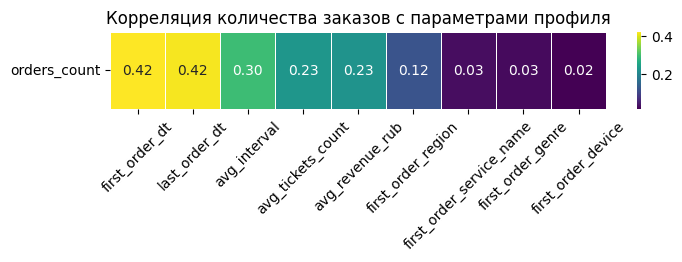

In [ ]:
def draw_heatmap(df, title):
    plt.figure(figsize=(8,1))
    plt.title(title)
    sns.heatmap(data=df, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.show()    
    
# Вычислим матрицу корреляций
corr_columns = ['avg_revenue_rub', 
                'avg_tickets_count', 
                'avg_interval', 
                'first_order_dt', 
                'first_order_dow', 
                'last_order_dt', 
                'first_order_region', 
                'first_order_device', 
                'first_order_service_name', 
                'first_order_genre']

interval_cols=['avg_revenue_rub', 
                'avg_tickets_count', 
                'avg_interval']

df_corr = phik.phik_matrix(df_user_profile[corr_columns + ['orders_count']],
                           interval_cols=interval_cols + ['orders_count'])[['orders_count']].sort_values(by='orders_count', ascending=False).drop('orders_count').T

# Построим тепловую карту корреляций
draw_heatmap(df_corr, "Корреляция количества заказов с параметрами профиля")

Корреляция с первой и последней датами заказа совпадает, потому что большинство пользователей сделали только один заказ или сделали все заказы в один день. Чтобы получить более точные данные, разобьем пользователей на категории по количеству заказов:

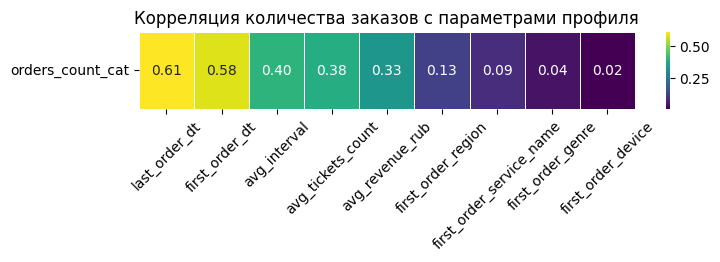

In [446]:
df_user_profile['orders_count_cat'] = pd.cut(df_user_profile['orders_count'], bins=[0, 1, 4, np.inf], labels=["1", "2-4", "5+"])

# Вычислим матрицу корреляций
df_corr = phik.phik_matrix(df_user_profile[corr_columns + ['orders_count_cat']],
                           interval_cols=interval_cols)[['orders_count_cat']].sort_values(by='orders_count_cat', ascending=False).drop('orders_count_cat').T

# Построим тепловую карту корреляций
draw_heatmap(df_corr, "Корреляция количества заказов с параметрами профиля")

Наибольшая корреляция количества заказов по категориям - с датами заказа и средним интервалом между заказами. Эти параметры взаимосвязаны, поэтому значения корреляции по ним близки друг к другу. В самом деле, на основании предшествующего анализа видно, что средний интервал между заказами в наибольшей степени характеризует постоянных пользователей. Следующие по значению корреляции параметры - среднее количество приобретенных билетов и средняя выручка по заказу. Наконец, наименьшее значение корреляции, указывающее не ее практическое отсутствие - у региона первого заказа, билетного оператора (эти параметры также взаимосвязаны), типа мероприятия и типа устройства.

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Анализ корреляции <a class="tocSkip"></h4>

<div style="border-radius: 10px" class="alert alert-success">
<b>Отлично ✅:</b>

* Здорово, что пробуешь сбалансировать разбиение на интервалы для количества заказов в противовес тому биннингу, который происходит автоматически в алгоритме Phik, когда мы передаем ему количественный признак.


* Корреляция интерпретируется верно! Phik всегда положительный и не дает информации о направленности, поэтому мы можем судить лишь о силе взаимосвязи. Говорить, что чем больше что-то одно, тем больше/меньше что-то другое, не корректно. Об этом мы можем лишь предполагать с точки зрения здравого смысла или судить по результатам дополнительного анализа.

</div>

   
<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* В анализ имеет смысл включить день недели.


* В отношении количества дней тут было бы интереснее посмотреть не усредненный показатель (в отношении него и без анализа все понятно), а, скорее, интервал между первыми двумя заказами - насколько он определяет дальнейшую судьбу клиента.


* Чтобы искать взаимосвязи с датами, нужно дробить их на отдельные составляющие, которые варьируются в данных (год, месяц, день недели, час, все категориальные, кроме года). Однако обрати внимание, что мы сейчас изучаем корреляцию с количеством заказов, но количество заказов, которые он успел сделать, непременно будет зависеть от того, насколько близко к концу охваченного нами периода он присоединился. Такая оценка не расскажет нам ничего интересного. Чтобы изучать, насколько сильно варьируется качество привлеченных клиентов (с точки зрения количества их последующих заказов) в зависимости от времени, необходимо фиксировать период обзора с момента их присоединения, чтобы все клиенты были в равных условиях при оценке.
  

*  В выводах было бы неплохо провести параллель с нашими предыдущими шагами анализа. Прокомментировать, почему высокая корреляция получается с одними признаками и низкая с другими. Что по итогу важно для манипулирования возвращаемостью клиентов, а что нет?

</div>

## 5. Выводы
- Для анализа были представлены данные в виде записей в связанных таблицах базы данных PostgreSQL. 
- На первом этапе данные были загружены при помощи SQL-запроса в датафрейм. В процессе предобработки была сокращена разрядность некоторых целочисленных столбцов, удалены выбросы и некорректные отрицательные значения выручки.
- Для анализа параметров, влияющих на совершение пользователями повторных заказов, был построен датафрейм с профилями пользователей, включающие агрегатные параметры по заказам этих пользователей.
- Были построены диаграммы доли возвращающихся пользователей по категориальным признакам - типу мероприятия, типу устройства, региону, билетному оператору. Оказалось, что типы мероприятий, по которым количество возвратов выше среднего - выставки, театры, концерты, стендап. Чаще возвращаются пользователи, сделавшие первый заказ со стационарных устройств, однако разница в данном случае слишком мала, чтобы утверждать о существовании зависимости. Установлено, что данные по региону и билетному оператору не являются релевантными, потому что наибольшая доля возвращающихся пользователей набюдается в регионах с очень низким количеством покупок, а явной прямой зависимости доли возвратов от доли пользователей не прослеживается.
- Затем было проанализировано распределение выручки отдельно для вернувшихся и не вернувшихся пользователей, а также - для пользователей, сделавших 2-4 и 5 или более заказов. Оказалось, что максимальное количество вернувшихся клиентов совершает совершает покупки в среднем на 503 р., не вернувшихся - примерно на 100 р. Медианная выручка по не вернувшимся пользователям ниже, чем по вернувшимся, однако средние значения находятся на одном уровне. Выручка от не вернувшихся пользователей имеет больший межквартильный интервал и концентрируется в диапазоне 141-839 р. Выручка от вернувшихся пользователей сконцентрирована в диапазоне 278-751 р. Медиана выручки от пользователей, сделавших 2-4 заказа меньше, чем медиана выручки от пользователей с 5 и более заказами (477 против 521 р.), а среднее значение выручки наоборот, чуть больше у пользователей с 2-4 заказами (557 против 544 р.)
- В результате анализа зависимости количества заказов от среднего количества билетов в заказе выяснено, что доля возвратов выше средней среди пользователей, приобретших в среднем 2-3 и 3-5 билетов. Однако доля возвратов в данном случае прямо зависит от доли пользователей в соответствующей категории.
- Установлена зависимость количества первых заказов от дня недели - наибольшее количество заказов сделано в дни, предшествующие выходным, и во вторник. Доля возвратов в зависимости от дня недели первого заказа различается незначительно.
- На основании анализа зависимости количества заказов от среднего интервала между ними и от времени жизни (времени, прошедшего с первого заказа) было установлено, что если интервал между заказами от 3 до 12 дней, велика вероятность, что такой пользователь станет постоянным (сделает 5 и более заказов). Но при увеличении интервала более 25-30 дней такой пользователь, скорее всего, не станет постоянным и не сделает более 2-4 заказов.
- Корреляционный анализ показал, что наибольшая корреляция количества заказов по категориям - с датами заказа и средним интервалом между заказами. Следующие по значению корреляции параметры - среднее количество приобретенных билетов и средняя выручка по заказу.

Наиболее важный параметр, по которому можно отличить постоянных пользователей, - средний интервал между заказами. Имеет смысл привлекать рекламой и акциями пользователей, у которых с даты последнего заказа прошло от 12 до 25 дней, и таким образом стимулировать их к повторному возвращению. 

Успешными "точками входа" для постоянных клиентов являются выставки, театры, концерты и стендап. В то же время спортивные мероприятия показывают долю возвратов ниже средней, поэтому стоит обратить внимание на этот сегмент клиентов и стимулировать повторные покупки акциями и скидками.

Ссылка на Git: git@github.com:tvorogov-code/ds-yandex.git

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Итоговые выводы <a class="tocSkip"></h4>


<div style="border-radius: 10px" class="alert alert-warning">
<b>Рекомендации💡:</b> 

* Итоговые выводы не очень содержательны. Отмечено, что наблюдается, но из этого не выделено никаких полезных инсайтов. Это большое упущение, ведь исследовательский анализ именно в этом и заключался. Стоит обратить внимание на рекомендации по выводам, оставленные под каждой задачей.
    


* По ркомендациям скудновато, характеристики первого заказа едва ли влияют на дальнейшее поведение клиентов. Стоит подумать о том, каким образом можно задействовать выявленные инсайты при планировании маркетинговых стратегий по привлечению новых и удержанию старых клиентов.
    

</div>

<div style="border:solid #D3D3D3 2px;  border-radius: 10px; padding: 15px">
<h3> Комментарий ревьюера <a class="tocSkip"></h3>
<h4> Публикация в Git <a class="tocSkip"></h4>
    
<div style="border-radius: 10px" class="alert alert-warning">
    
<b>Рекомендации💡:</b> Твой репозиторий непубличный, посмотреть не могу. Сейчас работу с Git сделали необязательной, но напомню про довольно критичные моменты.

* <span style="color:Red;">В репозитории не должно быть опубликовано данных и ключей для доступа к ним (как в `.env`, так и в самой тетрадке, в том числе в тексте задания), это считается засекреченной информацией. Можно оставить лишь `env_exaple.txt`, чтобы читатели, желающие запустить код, вставили туда свои собственные ключи. Сам `.env` необходимо отправить в игнорирование. (Обрати только внимание, что если ключи уже были случайно опубликованы, то после удаления из репозитория они все равно останутся в истории коммитов, поэтому ее тоже нужно почистить, хотя это и не очень простой процесс.) </span>
    
    
* <span style="color:Red;">Репозиторий должен содержать технические файлы: `.gitignore` (в котором мы как раз указываем, какие файлы чисто локальные - `env`, `venv`, `.ipynb_checkpoints` и так далее, их нужно игнорировать при совершении коммитов) и `requirements.txt` (чтобы зафиксировать версии библиотек, которые были использованы, и твой код гарантированно у всех воспроизводился).</span>

    

* Публикуемая тетрадка должна быть с выполненными ячейками. Без этого она довольно бесполезна, поскольку читатель не сможет ее запустить самостоятельно, так как у него нет доступа к данным.


* Стоит заполнить `readme` полезной информацией о проекте, зафиксировать цели, указать ключевые моменты и полученные выводы.

</div>


<div style="border:solid Green 2px; border-radius: 10px;  padding: 40px">
<h3>Общий вывод по проекту <a class="tocSkip"></h3>
    
Андрей, спасибо за твой проект! У тебя хорошая работа! В тебе видны зачатки будущего профессионала своего дела :) Однако есть еще моменты, которые требуют твоего внимания. Кратко пройдусь по впечатлениям. 
    
**Полнота:** 
    
* <span style="color:Red;">Необходимо расширить предобработку данных. Проверка на наличие явных, неявных, неполных дубликатов и невалидных значений - одни из важных этапов предобработки по умолчанию.</span>
* <span style="color:Red;">Каждый шаг требует пояснений, каждый раздел - резюмирующих выводов.</span>
    
**Корректность:** 

* <span style="color:Red;">Заполнение пропусков в количестве дней между заказами в данном проекте нам не доступно. Любое значение будет искажать статистические показатели. Также учитываем, что интрвалов меньше количества заказов.</span>
* <span style="color:Red;">При создании профилей сортировать необходимо по времени, чтобы корректно упорядочить заказы в течение дня.</span>
* <span style="color:Red;">При наложении гистограмм необходимо нормализовать высоту бинов, чтобы количество наблюдений не влияло на наше восприятие.</span>

**Аналитическая проницательность:** ты верно подмечаешь ключевые нюансы данных! Местами можно чуть углубить суждения, фиксировать не только то, что наблюдаем, но и предполагать, почему получилось именно так.

**Эффективность кода:** по этому критерию в целом тоже все супер! В некоторых местах можно использовать чуть более удобные и компактные методы, зафункционалить повторяющиеся действия. Стоит обратить внимание на длину строки с кодом -  согдасно стандартам не больше 79 символов.

**Оформление:** им тоже важно не пренебрегать! Оформление тесно связано с удобством восприятия предоставляемой информации и созданием впечатления о работе. Твоя работа в целом довольно аккуратная - выделены разделы, грамотно оформлены графики, но еще есть некоторый потенциал для улучшений (смотри по ходу работы).

**Желаю удачи и жду твой проект на повторное ревью!** 😉
    
<img src="https://99px.ru/sstorage/86/2015/12/image_86271215043043632690.gif" />